# Inferred Metabolic and Medium-Chain Carboxylic Acid Potential: Publication Figures

This notebook generates the publication-quality figures for the taxonomic composition, predicted metabolic functions, and medium-chain carboxylic acid (MCCA) production potential of mixed microbial communities described in Hernández-Gonzalez et al. (2026).

The analyses include two experimental datasets:

1. Batch inoculum proportion experiment.
2. Chain-elongation sequencing batch reactor (SBR) samples (Batches 2–5).

The notebook reproduces all figures related to microbial community composition and PICRUSt2-based functional inference used in the manuscript.

# Load packages

In [44]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import scipy.stats as stats
from scipy.stats import spearmanr


# Publication style

Shared style system applied to every figure in this notebook, targeting the visual
standard of high-impact journals. Formats: PDF for the manuscript; TIFF at 600 dpi and PNG at 300 dpi.


In [45]:
# Publication-quality style system (applies to every figure below)

# Global rcParams: sans-serif type, editable vector text, minimal chrome 
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,      # embed text as editable, not outlined curves (required by most journals)
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#000000",
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "legend.fontsize": 8,
    "legend.frameon": False,
    "legend.title_fontsize": 9,
    "figure.dpi": 120,        # on-screen preview only; export DPI is set explicitly in save_fig()
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

# Figure sizing (inches). Bioresource Technology / Springer full text width
#      is ~17.5 cm (~6.9 in); Nature double-column is ~183 mm (~7.2 in). These
#      sizes work cleanly across both without redesigning each panel. 
FIGSIZE_BAR      = (7.2, 4.3)   # horizontal stacked bar charts (composition, function, bioproduct)
FIGSIZE_HEATMAP  = (7.2, 5.2)   # Spearman correlation heatmaps
FIGSIZE_PCA      = (4.0, 3.8)   # single-column ordination plot

# Colorblind-safe diverging colormap for all heatmaps (kept as RdBu_r: it is
#      already colorblind-safe and print-safe; centralized here for consistency) 
CMAP_DIVERGING = "RdBu_r"


def style_axes(ax=None):
    """Apply consistent minimal-chrome styling to a bar/scatter axes."""
    ax = ax or plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333")
    ax.spines["bottom"].set_color("#333333")
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(width=0.8, colors="#333333")
    return ax


def dedupe_legend(ax=None, **legend_kwargs):
    """Deduplicate legend handles/labels (safe even if there are no duplicates)
    and apply consistent, unobtrusive legend styling."""
    ax = ax or plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    defaults = dict(frameon=False, fontsize=8, handlelength=1.2, handletextpad=0.5,
                     labelspacing=0.35, borderaxespad=0.0)
    defaults.update(legend_kwargs)
    return ax.legend(by_label.values(), by_label.keys(), **defaults)


def save_fig(fig_dir, name, fig=None):
    """Save a figure in the three formats journals commonly require:
    PDF (vector, primary submission format), TIFF at 600 dpi (raster
    requirement for combination art in most journals), and PNG at 300 dpi
    (quick preview / supplementary use). Uses tight bounding boxes throughout.
    """
    fig = fig or plt.gcf()
    fig_dir = Path(fig_dir)
    fig.savefig(fig_dir / f"{name}.pdf", bbox_inches="tight", pad_inches=0.05)
    fig.savefig(fig_dir / f"{name}.tiff", dpi=600, bbox_inches="tight", pad_inches=0.05)
    fig.savefig(fig_dir / f"{name}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)


# File Paths

In [46]:
# select dataset
DATASET = "SBR"   # "inocula", "proportions","inocula_proportions" or "SBR"

# Paths
PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_1_DIR = RESULTS_DIR / "results_1_checked"
RESULTS_3_DIR = RESULTS_DIR / "results_3_checked"

YIELDS_SBR_DIR = PROJECT_ROOT / "data" / "Carboxilic_acid_yields"/"yields_in_SBR"
YIELDS_INOCULUM_PROPORTIONS_DIR = PROJECT_ROOT / "data" / "Carboxilic_acid_yields"/ "yields_in_inoculum_proportions"


# Pure culture data. Different primers were used
inocula_data_results_1 = RESULTS_1_DIR / "inocula" / "dada2_trimmed_F260_R215"
proportions_data_results_1 = RESULTS_1_DIR / "proportions" / "dada2_trimmed_F245_R183"

# SBR data of Batch 2 to 6. Stand by phase and Batch 1 (sequenced with different primers) were excluded from the analysis 
SBR_data_B2toB6_results_3 = RESULTS_3_DIR / "SVR" / "dada2_trimmed_F275_R245" 

#fig_dir_1 = inocula_data_results_1 / "figures"
#fig_dir_2 = proportions_data_results_1 / "figures"
fig_dir_3 = SBR_data_B2toB6_results_3 / "figures"
fig_dir_combined = RESULTS_1_DIR / "figures_inocula_proportions_combined" 


for fig_dir in [fig_dir_3, fig_dir_combined]:
    fig_dir.mkdir(parents=True, exist_ok=True)

In [47]:
# Dataset configuration. Specifies the base path and figure directory for each dataset.
dataset_paths = {
    #"inocula": {
    #    "base": inocula_data_results_1,
    #    "yields_dir": YIELDS_INOCULUM_PROPORTIONS_DIR,
    #    "fig_dir": fig_dir_1
    #},
    #"proportions": {
    #    "base": proportions_data_results_1,
    #    "yields_dir": YIELDS_INOCULUM_PROPORTIONS_DIR,
    #    "fig_dir": fig_dir_2
    #},
    "SBR": {
        "base": SBR_data_B2toB6_results_3,
        "yields_dir": YIELDS_SBR_DIR,
        "fig_dir": fig_dir_3
    }, 
    "inocula_proportions": {
        # "base" is intentionally absent -- this combined mode loads BOTH
        # inocula and proportions bases separately (see loading cell below),
        # because the two datasets were sequenced with different primers
        # and must be taxonomy-merged independently before combining.
        "bases": {
            "inocula": inocula_data_results_1,
            "proportions": proportions_data_results_1,
        },
        "yields_dir": YIELDS_INOCULUM_PROPORTIONS_DIR,
        "fig_dir": fig_dir_combined
    }
}

cfg = dataset_paths[DATASET] # Defined above: "inocula", "proportions", or "SBR"


In [48]:
# Sample renaming mappings for each dataset

replace_mappings = {
    "inocula": {
        "SVR-R1-MS28F": "Wine", # this name change was confirmed by Sharon 
        "SVR-VT-MS28": "Rumen", 
    },

    "proportions": {
        "SVR-01-S151": "R80W20",
        "SVR-02-S163": "R50W50",
        "SVR-03-S175": "R20W80"
    },
    "SBR": {
        "SVR2": "Batch 2",
        "SVR3": "Batch 3",
        "SVR5": "Batch 4",
        "SVR6": "Batch 5"
    }
}

replace_mapping = replace_mappings.get(DATASET, {})


In [49]:
def _standardize_taxon_column(df):
    for col in ["taxon", "OTU", "feature_id"]:
        if col in df.columns:
            return df.rename(columns={col: "taxon_id"})
    raise ValueError("No taxon column found!")


def load_and_prepare(base):
    """Load EC/KO/taxonomy for one dataset base, standardize columns, and
    merge taxonomy in -- all within that dataset's own taxon_id space.
    Returns (ec_tax, ko_tax) for this one dataset only."""
    ec_file_ = base / "picrust2_out" / "EC_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
    ko_file_ = base / "picrust2_out" / "KO_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
    taxa_file_ = base / "taxa_export" / "taxonomy.tsv"

    ec_ = pd.read_csv(ec_file_, sep="\t")
    ko_ = pd.read_csv(ko_file_, sep="\t")
    tax_ = pd.read_csv(taxa_file_, sep="\t")

    tax_ = tax_.rename(columns={"Feature ID": "taxon_id", "Taxon": "Taxon_label"})
    ec_ = _standardize_taxon_column(ec_)
    ko_ = _standardize_taxon_column(ko_)

    ec_tax_ = ec_.merge(tax_, on="taxon_id", how="left")
    ko_tax_ = ko_.merge(tax_, on="taxon_id", how="left")
    return ec_tax_, ko_tax_


if DATASET == "inocula_proportions":
    fig_dir = cfg["fig_dir"]

    # Load + taxonomy-merge each sub-dataset in its OWN taxon_id space
    ec_tax_inocula, ko_tax_inocula = load_and_prepare(cfg["bases"]["inocula"])
    ec_tax_proportions, ko_tax_proportions = load_and_prepare(cfg["bases"]["proportions"])

    # Apply each dataset's own sample-renaming BEFORE concatenation
    ec_tax_inocula["sample"] = ec_tax_inocula["sample"].replace(replace_mappings["inocula"])
    ko_tax_inocula["sample"] = ko_tax_inocula["sample"].replace(replace_mappings["inocula"])
    ec_tax_proportions["sample"] = ec_tax_proportions["sample"].replace(replace_mappings["proportions"])
    ko_tax_proportions["sample"] = ko_tax_proportions["sample"].replace(replace_mappings["proportions"])

    # Concatenate -- safe because both frames already carry genus/class-level
    # taxonomy (comparable across regions), not raw ASV IDs (not comparable).
    ec_tax = pd.concat([ec_tax_inocula, ec_tax_proportions], ignore_index=True)
    ko_tax = pd.concat([ko_tax_inocula, ko_tax_proportions], ignore_index=True)

    print("Combined inocula+proportions samples:", ec_tax["sample"].unique())
    print("EC_tax shape (combined):", ec_tax.shape)
    print("KO_tax shape (combined):", ko_tax.shape)

else:
    # ---- Single-dataset path (inocula / proportions / SBR) ----
    ec_file = cfg["base"] / "picrust2_out" / "EC_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
    ko_file = cfg["base"] / "picrust2_out" / "KO_metagenome_out" / "pred_metagenome_contrib.tsv.gz"
    taxa_file = cfg["base"] / "taxa_export" / "taxonomy.tsv"
    fig_dir = cfg["fig_dir"]

    ec = pd.read_csv(ec_file, sep="\t")
    ko = pd.read_csv(ko_file, sep="\t")
    tax = pd.read_csv(taxa_file, sep="\t")

    print("EC columns:", ec.columns.tolist())
    print("KO columns:", ko.columns.tolist())
    print("TAX columns:", tax.columns.tolist())


EC columns: ['sample', 'function', 'taxon', 'taxon_abun', 'taxon_rel_abun', 'genome_function_count', 'taxon_function_abun', 'taxon_rel_function_abun', 'norm_taxon_function_contrib']
KO columns: ['sample', 'function', 'taxon', 'taxon_abun', 'taxon_rel_abun', 'genome_function_count', 'taxon_function_abun', 'taxon_rel_function_abun', 'norm_taxon_function_contrib']
TAX columns: ['Feature ID', 'Taxon', 'Confidence']


In [50]:
if DATASET != "inocula_proportions":
    r = pd.read_csv(taxa_file)
    r.head()
else:
    print("(skipped -- combined mode has two taxonomy files, already merged in the loading cell above)")


In [51]:
if DATASET == "inocula_proportions":
    print(ec_tax["sample"].unique())
else:
    print(ec["sample"].unique())


['SVR2' 'SVR3' 'SVR5' 'SVR6']


In [52]:
if DATASET != "inocula_proportions":
    # Stardardize column names for taxon identifiers across datasets
    tax = tax.rename(columns={
        "Feature ID": "taxon_id",
        "Taxon": "Taxon_label"
    })
    ec = _standardize_taxon_column(ec)
    ko = _standardize_taxon_column(ko)
else:
    print("(skipped -- already standardized per-dataset inside load_and_prepare())")


In [53]:
if DATASET != "inocula_proportions":
    replace_mapping = replace_mappings.get(DATASET, {})
    ec["sample"] = ec["sample"].replace(replace_mapping)
    ko["sample"] = ko["sample"].replace(replace_mapping)
    print("Samples after renaming:", ec["sample"].unique())
else:
    print("(skipped -- renaming already applied per-dataset before concatenation)")


Samples after renaming: ['Batch 2' 'Batch 3' 'Batch 4' 'Batch 5']


In [54]:
# Fast mode
TEST_MODE = False  # In test mode keep only 2 samples

if TEST_MODE:
    print("\nRunning in TEST MODE (2 samples)...")
    if DATASET == "inocula_proportions":
        selected_samples = ec_tax["sample"].drop_duplicates().head(2).tolist()
        print("Selected samples:", selected_samples)
        ec_tax = ec_tax[ec_tax["sample"].isin(selected_samples)]
        ko_tax = ko_tax[ko_tax["sample"].isin(selected_samples)]
        print("Filtered EC_tax shape:", ec_tax.shape)
        print("Filtered KO_tax shape:", ko_tax.shape)
    else:
        selected_samples = ec["sample"].drop_duplicates().head(2).tolist()
        print("Selected samples:", selected_samples)
        ec = ec[ec["sample"].isin(selected_samples)]
        ko = ko[ko["sample"].isin(selected_samples)]
        print("Filtered EC shape:", ec.shape)
        print("Filtered KO shape:", ko.shape)


In [55]:
if DATASET != "inocula_proportions":
    # Fix column names for taxonomy to match EC/KO
    tax = tax.rename(columns={
        "Feature ID": "taxon_id",
        "Taxon": "Taxon_label"
    })
    ec = ec.rename(columns={"taxon": "taxon_id"})
    ko = ko.rename(columns={"taxon": "taxon_id"})

    print("\nMerging taxonomy...")
    ec_tax = ec.merge(tax, on="taxon_id", how="left")
    ko_tax = ko.merge(tax, on="taxon_id", how="left")
    print("EC_tax shape:", ec_tax.shape)
    print("KO_tax shape:", ko_tax.shape)

    ko_tax = ko_tax.rename(columns={"taxon": "taxon_id", "Taxon": "Taxon_label"})
    ec_tax = ec_tax.rename(columns={"taxon": "taxon_id", "Taxon": "Taxon_label"})
else:
    print("(skipped -- ec_tax/ko_tax already fully merged in the combined-loading cell above)")



Merging taxonomy...
EC_tax shape: (443135, 11)
KO_tax shape: (900444, 11)


ec_tax working
ko_tax misses Taxon_label. CHECK picrust

# 1. Taxonomy composition 

In [56]:
# copy ec_tax to ec_tax0 for genus to class lookup

ec_tax0 = ec_tax.copy()

In [57]:
# Extract genus + class from the taxonomy lineage

def extract_tax_level(tax_lineage, prefix):
    if pd.isna(tax_lineage):
        return "Unclassified"
    for level in tax_lineage.split(";"):
        if level.startswith(prefix) and level != prefix:
            return level.replace(prefix, "")
    return "Unclassified"

ec_tax0["Taxon_genus"] = ec_tax0["Taxon_label"].apply(lambda x: extract_tax_level(x, "g__"))
ec_tax0["Taxon_class"] = ec_tax0["Taxon_label"].apply(lambda x: extract_tax_level(x, "c__"))

In [58]:
df = ec_tax0.groupby(["sample", "Taxon_genus"])["taxon_abun"].sum().reset_index()
df["rel"] = df.groupby("sample")["taxon_abun"].transform(lambda x: x / x.sum())

## Figure 1: Taxnomic composition

This figure is made from 16S analysis in qiime2. 

10 genera exceed 5% relative abundance in at least one sample, WITHIN their own primer group:
  V3-V4: ['Dialister', 'Lachnospiraceae_NK3A20_group', 'Lactobacillus', 'Ligilactobacillus', 'Limosilactobacillus', 'Olsenella', 'Prevotella_7', 'Syntrophococcus', 'Unclassified_Clostridia', '[Eubacterium]_nodatum_group']
NOTE: found 18 classes, expected 14. Palette will still work, but double-check this is intentional.
Exported composition data for SBR.


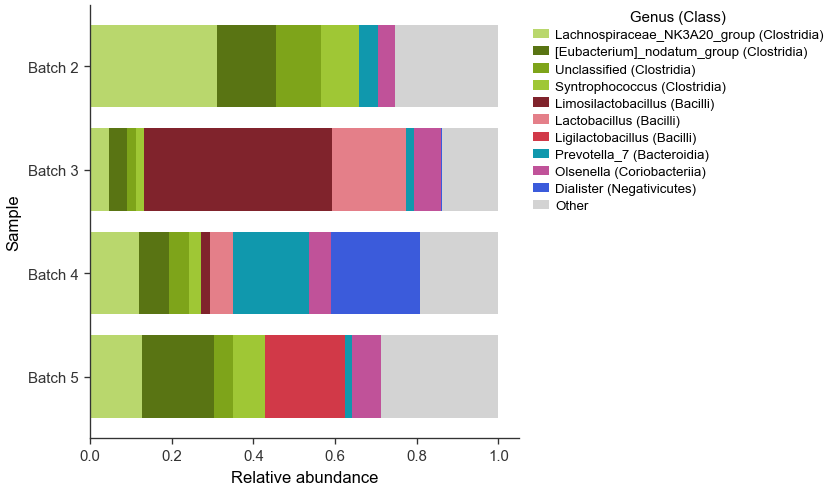

In [59]:
# Master class -> genus color system (shared by every figure below)

N_EXPECTED_CLASSES = 14
MAX_SHADES_PER_CLASS = 5

CURATED_CLASS_COLORS = {
    "Clostridia":            "#94C11F",
    "Bacilli":               "#D63A4A",
    "Bacteroidia":           "#1098AD",
    "Actinobacteria":        "#F08C46",
    "Gammaproteobacteria":   "#2F9E44",
    "Alphaproteobacteria":   "#7950F2",
    "Negativicutes":         "#3B5BDB",
    "Coriobacteriia":        "#C05299",
    "Spirochaetia":          "#3BC9DB",
    "Synergistia":           "#A03E5D",
    "Limnochordia":          "#6D9F3A",
    "Symbiobacteriia":       "#5C7CFA",
    "Syntrophobacteria":     "#C56A3D",
    "Methanobacteria":       "#2B8A8A",
    "Thermoplasmata":        "#E9B44C",
    "Saccharimonadia":       "#8B5CF6",
    "Vampirivibrionia":      "#E56B8A",
    "Planctomycetes":        "#D97B3D",
    "Fibrobacteria":         "#3FA7D6",
    "Cyanobacteriia":        "#3FAF82",
}


def build_class_base_colors(all_classes):
    classes_sorted = sorted(all_classes)
    n = len(classes_sorted)
    if n != N_EXPECTED_CLASSES:
        print(f"NOTE: found {n} classes, expected {N_EXPECTED_CLASSES}. "
              f"Palette will still work, but double-check this is intentional.")
    result = {} 
    uncovered = [c for c in classes_sorted if c not in CURATED_CLASS_COLORS]
    if uncovered:
        fallback_pool = [c for c in sns.color_palette("husl", len(uncovered) + 6).as_hex()
                          if max(abs(int(c[1:3], 16) - int(c[3:5], 16)),
                                 abs(int(c[3:5], 16) - int(c[5:7], 16))) > 15][:len(uncovered)]
        for cls, color in zip(uncovered, fallback_pool):
            result[cls] = color
            print(f"NOTE: class '{cls}' not in CURATED_CLASS_COLORS -- assigned fallback color {color}.")
    for cls in classes_sorted:
        if cls in CURATED_CLASS_COLORS:
            result[cls] = CURATED_CLASS_COLORS[cls]
    return result


def shade_variants(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    factors = np.linspace(1.35, 0.6, n) if n > 1 else [1.0]
    out = []
    for f in factors:
        if f >= 1:
            shade = base + (1 - base) * (f - 1)
        else:
            shade = base * f
        out.append(mcolors.to_hex(np.clip(shade, 0, 1)))
    return out


def get_genus_colors(genera_by_class, class_base_colors):
    taxa_colors_local = {}
    for cls, genera in genera_by_class.items():
        if len(genera) > MAX_SHADES_PER_CLASS:
            print(f"WARNING: class '{cls}' has {len(genera)} genera in this figure "
                  f"(> {MAX_SHADES_PER_CLASS}); shades may become hard to distinguish. "
                  f"Consider raising ABUNDANCE_THRESHOLD.")
        base = class_base_colors.get(cls, "#7f7f7f")
        shades = shade_variants(base, len(genera))
        for genus, shade in zip(genera, shades):
            key = f"Unclassified_{cls}" if genus == "Unclassified" else genus
            taxa_colors_local[key] = shade
    return taxa_colors_local

# =====================================================
# Genus-level composition -- threshold applied PER PRIMER GROUP (not
# pooled across all samples, not strict-per-cell). A genus qualifies for
# a primer group if it clears ABUNDANCE_THRESHOLD in at least one sample
# WITHIN that group; once qualified, its real value is shown in every
# sample of that SAME group (never borrowed across groups). This closes
# the cross-primer "unfair borrowing" confound while preserving full,
# honest information for every WITHIN-group comparison (the mixing
# gradient, the SBR trajectory, Rumen vs Wine). 
#
# NOTE: "primer_group" ("V1-V2"/"V6-V8"/"V3-V4") is an INTERNAL grouping
# key used only for the qualification computation below. It is never
# merged into df_pivot and never touches sample_name_map / desired_order
# -- the plotted x-axis / legend labels remain "Rumen", "Wine",
# "Rumen 80 / Wine 20", "Batch 2", etc., exactly as before.
# =====================================================

ABUNDANCE_THRESHOLD = 0.05   # 5% -- relative abundance is bounded to [0,1]

# Genus -> class lookup (majority class), used for legend labels/ordering only
genus_to_class = (
    ec_tax0.groupby("Taxon_genus")["Taxon_class"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)

# Aggregate by (sample, genus, class) so different classes' "Unclassified"
# entries stay distinguishable rather than merging into one bucket.
df = (
    ec_tax0.groupby(["sample", "Taxon_genus", "Taxon_class"], as_index=False)["taxon_abun"]
    .sum()
)

def _genus_plot_key(row):
    # "Unclassified" is re-keyed to ITS OWN row's real class, not a global
    # majority class for the whole genus label.
    g = row["Taxon_genus"]
    if g == "Unclassified":
        cls = row["Taxon_class"] if pd.notna(row["Taxon_class"]) else "Unclassified"
        return f"Unclassified_{cls}"
    return g

df["Taxon_genus_plot"] = df.apply(_genus_plot_key, axis=1)
df = df.groupby(["sample", "Taxon_genus_plot"], as_index=False)["taxon_abun"].sum()
df["rel"] = df.groupby("sample")["taxon_abun"].transform(lambda x: x / x.sum())

# ---- Per-primer-group genus qualification ----
primer_group_map = {
    "Rumen": "V1-V2", "Wine": "V1-V2",
    "R80W20": "V6-V8", "R50W50": "V6-V8", "R20W80": "V6-V8",
    "Batch 2": "V3-V4", "Batch 3": "V3-V4", "Batch 4": "V3-V4", "Batch 5": "V3-V4",
}

df["primer_group"] = df["sample"].map(primer_group_map)

_unmapped = df.loc[df["primer_group"].isna(), "sample"].unique()
if len(_unmapped) > 0:
    print(f"WARNING: these samples have no primer_group mapping and will be "
          f"excluded from genus qualification: {list(_unmapped)}")

max_rel_per_genus_per_group = (
    df.groupby(["primer_group", "Taxon_genus_plot"])["rel"].max()
)

plotted_genera_final = set(
    max_rel_per_genus_per_group[max_rel_per_genus_per_group >= ABUNDANCE_THRESHOLD]
    .index.get_level_values("Taxon_genus_plot")
)

print(f"{len(plotted_genera_final)} genera exceed {ABUNDANCE_THRESHOLD:.0%} "
      f"relative abundance in at least one sample, WITHIN their own primer group:")
for pg in df["primer_group"].dropna().unique():
    qualifying_here = max_rel_per_genus_per_group[pg][max_rel_per_genus_per_group[pg] >= ABUNDANCE_THRESHOLD]
    print(f"  {pg}: {list(qualifying_here.index)}")

df["Taxon_plot"] = df["Taxon_genus_plot"].where(
    df["Taxon_genus_plot"].isin(plotted_genera_final), "Other"
)

# Drop the internal-only column before continuing -- ensures it can never
# accidentally leak into downstream aggregation, ordering, or plot labels
df = df.drop(columns=["primer_group"])

df = df.groupby(["sample", "Taxon_plot"], as_index=False)["rel"].sum()

df_pivot = df.pivot_table(index="sample", columns="Taxon_plot", values="rel", fill_value=0)

# =====================================================
# Colors: master palette, merge into taxa_colors
# =====================================================

class_base_colors = build_class_base_colors(ec_tax0["Taxon_class"].unique())

taxa_colors = {}

_genera_here = [g for g in df_pivot.columns if g != "Other"]
_genera_by_class_here = {}
for g in _genera_here:
    if g.startswith("Unclassified_"):
        cls = g.split("Unclassified_", 1)[1]
    else:
        cls = genus_to_class.get(g, "Unclassified")
    _genera_by_class_here.setdefault(cls, []).append(g)

_missing_classes = [c for c in _genera_by_class_here if c not in class_base_colors]
if _missing_classes:
    print(f"Extending class_base_colors for previously-missing classes: {_missing_classes}")
    class_base_colors.update(build_class_base_colors(list(class_base_colors.keys()) + _missing_classes))

taxa_colors.update(get_genus_colors(_genera_by_class_here, class_base_colors))
taxa_colors["Other"] = "#d3d3d3"
taxa_colors["Unclassified"] = "#7f7f7f"

_still_gray = [g for g in _genera_here if taxa_colors.get(g) in ("#7f7f7f", "lightgray", "#d3d3d3")]
if _still_gray:
    print(f"WARNING: these genera are STILL gray after the fix -- investigate further: {_still_gray}")

# Order columns: group by class (adjacent hues), then by abundance within class
genus_abun = df.groupby("Taxon_plot")["rel"].sum()
class_order = sorted(
    _genera_by_class_here.keys(),
    key=lambda cls: sum(genus_abun.get(g, 0) for g in _genera_by_class_here[cls]),
    reverse=True,
)
for cls in _genera_by_class_here:
    _genera_by_class_here[cls].sort(key=lambda g: genus_abun.get(g, 0), reverse=True)
col_order = [g for cls in class_order for g in _genera_by_class_here[cls]]
if "Other" in df_pivot.columns:
    col_order.append("Other")
df_pivot = df_pivot[col_order]

def genus_display_label(g):
    if g == "Other":
        return "Other"
    if g.startswith("Unclassified_"):
        return f"Unclassified ({g.split('Unclassified_', 1)[1]})"
    return f"{g} ({genus_to_class.get(g, 'Unclassified')})"

display_labels = {g: genus_display_label(g) for g in df_pivot.columns}

# =====================================================
# Sample renaming / ordering (unaffected by primer_group -- separate
# short-code -> long-display-name mapping, as before)
# =====================================================

if DATASET in ("inocula", "proportions"):
    sample_name_map = {
        "Rumen": "Rumen", "Wine": "Wine",
        "R80W20": "Rumen 80 / Wine 20", "R50W50": "Rumen 50 / Wine 50",
        "R20W80": "Rumen 20 / Wine 80",
    }
    df_pivot = df_pivot.rename(index=sample_name_map)
    desired_order = ["Rumen", "Wine", "Rumen 80 / Wine 20", "Rumen 50 / Wine 50", "Rumen 20 / Wine 80"]
    desired_order = [s for s in desired_order if s in df_pivot.index]
    df_pivot = df_pivot.reindex(desired_order).iloc[::-1]
elif DATASET == "inocula_proportions":
    sample_name_map = {
        "R80W20": "Rumen 80 / Wine 20", "R50W50": "Rumen 50 / Wine 50",
        "R20W80": "Rumen 20 / Wine 80",
    }
    df_pivot = df_pivot.rename(index=sample_name_map)
    desired_order = ["Rumen", "Wine", "Rumen 80 / Wine 20", "Rumen 50 / Wine 50", "Rumen 20 / Wine 80"]
    desired_order = [s for s in desired_order if s in df_pivot.index]
    df_pivot = df_pivot.reindex(desired_order).iloc[::-1]
else:  # SBR
    desired_order_SBR = ["Batch 2", "Batch 3", "Batch 4", "Batch 5"]
    desired_order_SBR = [s for s in desired_order_SBR if s in df_pivot.index]
    df_pivot = df_pivot.reindex(desired_order_SBR).iloc[::-1]


# ---- Export plot-ready composition data for cross-notebook figure assembly ----
import pickle

def _rebuild_display_label(g):
    if g == "Other":
        return "Other"
    if g.startswith("Unclassified_"):
        return f"Unclassified ({g.split('Unclassified_', 1)[1]})"
    return f"{g} ({genus_to_class.get(g, 'Unclassified')})"

# Rebuilt directly from df_pivot's own columns -- immune to whatever any
# other cell did to the shared "display_labels" variable in between.
safe_display_labels = {g: _rebuild_display_label(g) for g in df_pivot.columns}

with open(fig_dir / f"composition_export_{DATASET}.pkl", "wb") as f:
    pickle.dump({
        "df_pivot": df_pivot,
        "taxa_colors": taxa_colors,
        "display_labels": safe_display_labels,
    }, f)
print(f"Exported composition data for {DATASET}.")

# =====================================================
# Plot -- horizontal stacked
# =====================================================

fig = plt.figure(figsize=FIGSIZE_BAR)
left = None
for col in df_pivot.columns:
    plt.barh(
        df_pivot.index,
        df_pivot[col],
        left=left,
        label=display_labels[col],
        color=taxa_colors.get(col, "lightgray"),
        height=0.8,
    )
    left = df_pivot[col] if left is None else left + df_pivot[col]

plt.xlabel("Relative abundance")
plt.ylabel("Sample")
style_axes()
dedupe_legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Genus (Class)")
plt.tight_layout()
save_fig(fig_dir, "genus_composition_stacked_bar")
plt.show()

In [60]:
# ---- Export plot-ready composition data for cross-notebook figure assembly ----
import pickle

with open(fig_dir / f"composition_export_{DATASET}.pkl", "wb") as f:
    pickle.dump({
        "df_pivot": df_pivot,
        "taxa_colors": taxa_colors,
        "display_labels": display_labels,
    }, f)
print(f"Exported composition data for {DATASET}.")

Exported composition data for SBR.


# 2. Functional analysis 


In [61]:
# Data preprocessing for functional inference

# Reduce data (TOP 20 functions)

top_functions = (
    ec_tax.groupby("function")["norm_taxon_function_contrib"]
    .sum()
    .nlargest(20)
    .index
)

# df filtering to top functions
ec_tax_filtered_top_functions = ec_tax0[ec_tax0["function"].isin(top_functions)]
print("number of top functions:", len(ec_tax_filtered_top_functions['function'].unique()))

number of top functions: 20


## Figure 2: top functions in community

Potential metabolic functions (represented through EC numbers) are ploted per batch experiment. Main Taxa Genera contributors are also plotted.

/var/folders/yb/_xf4lxss6n9g0n8frp24vv7w0000gn/T/ipykernel_1064/526407842.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ec_tax0.groupby(["sample", "function"])["taxon_rel_function_abun"]


number of top functions (union across samples): 36
15 genera exceed 5% contribution in at least one sample-function cell, WITHIN their own primer group:
  V3-V4: ['Acetitomaculum', 'Acidaminococcus', 'Candidatus_Saccharimonas', 'Dialister', 'Lachnospiraceae_NK3A20_group', 'Lactobacillus', 'Ligilactobacillus', 'Limosilactobacillus', 'Methanobrevibacter', 'Olsenella', 'Prevotella_7', 'Syntrophococcus', 'Treponema', 'Unclassified', '[Eubacterium]_nodatum_group']
Plotting sample Batch 2...


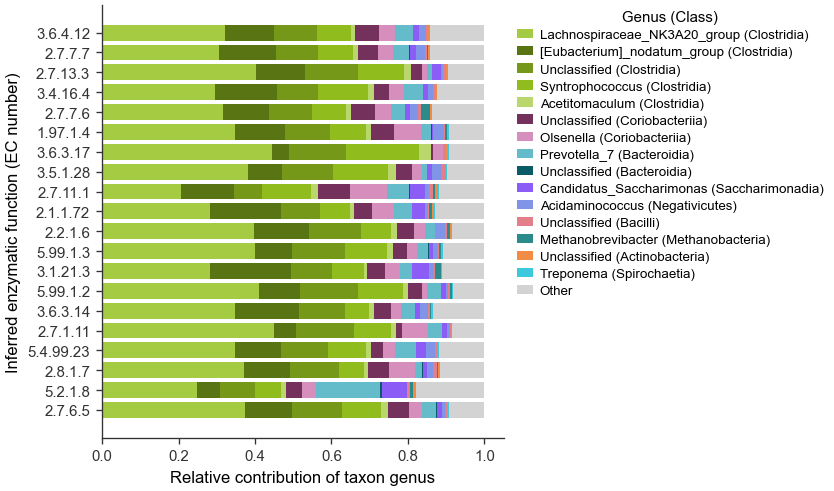

Plotting sample Batch 3...


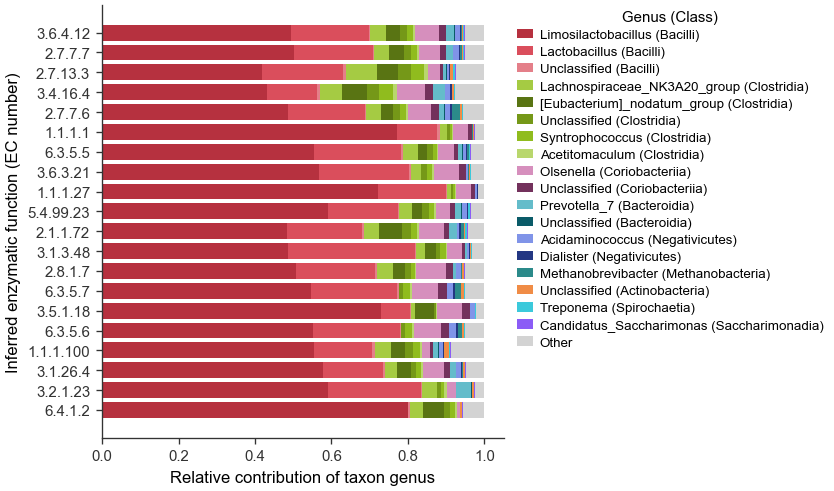

Plotting sample Batch 4...


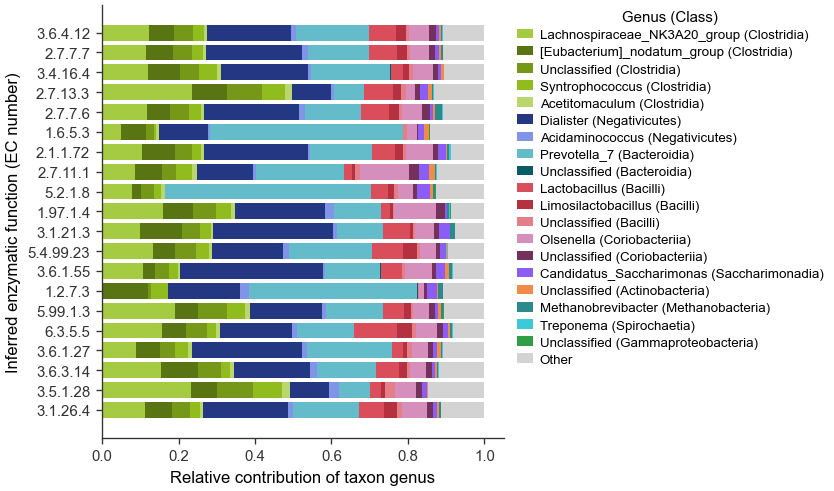

Plotting sample Batch 5...


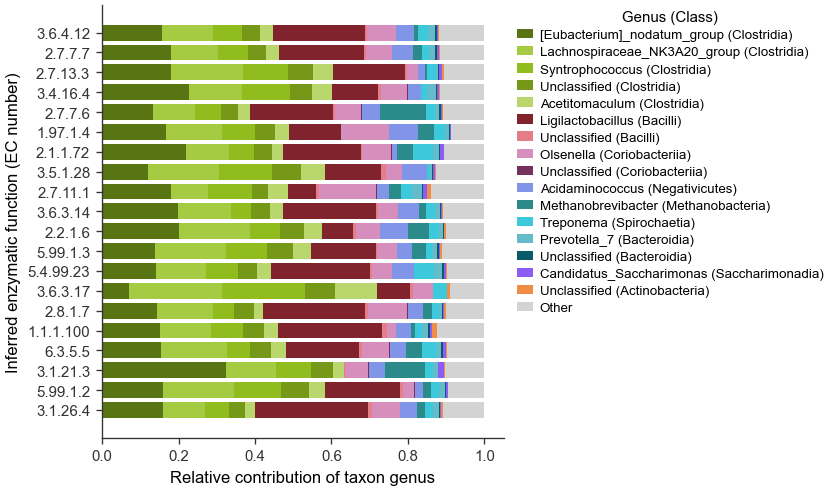

In [62]:
# =====================================================
# Figure 2: top functions in community -- FACET VERSION
# Self-contained: function selection, genus selection, and faceted
# plotting all live in one cell.
#
# Two metrics, used deliberately for two different questions:
#   - taxon_rel_function_abun     -> WHICH functions are most abundant
#   - norm_taxon_function_contrib -> WHO contributes to those functions
#
# Genus selection: threshold applied PER PRIMER GROUP (see step 3 below
# and Figure 1 for full rationale). Rumen/Wine (V1-V2), the mixing ratios
# (V6-V8), and SBR batches (V3-V4) are treated as separate groups so a
# genus can never earn a name using data from a different primer's samples.
# =====================================================

ABUNDANCE_THRESHOLD = 0.05   # -- norm_taxon_function_contrib is bounded to [0,1]

# ---- 1. Select top-20 functions PER SAMPLE, by real abundance ----
top_functions_per_sample = (
    ec_tax0.groupby(["sample", "function"])["taxon_rel_function_abun"]
    .sum()
    .reset_index()
    .groupby("sample", group_keys=False)
    .apply(lambda x: x.nlargest(20, "taxon_rel_function_abun"))
)

ec_tax_filtered_top_functions = ec_tax0.merge(
    top_functions_per_sample[["sample", "function"]],
    on=["sample", "function"]
)
print("number of top functions (union across samples):",
      ec_tax_filtered_top_functions["function"].nunique())


# ---- 2. Aggregate: sample + function + genus + class, keeping BOTH metrics ----
df_filtered_top_functions = (
    ec_tax_filtered_top_functions
    .groupby(
        ["sample", "function", "Taxon_genus", "Taxon_class"],
        as_index=False
    )[["taxon_rel_function_abun", "norm_taxon_function_contrib"]]
    .sum()
)


# ---- 3. Genus selection: threshold applied PER PRIMER GROUP, not pooled
# across all samples, and not strict-per-cell either. A genus qualifies
# for a primer group if it clears ABUNDANCE_THRESHOLD in at least one
# (sample, function) cell WITHIN that group; once qualified, its real
# value is shown in every sample of that SAME group (never borrowed
# across groups). See Figure 1 for the full rationale.

primer_group_map = {
    "Rumen": "V1-V2", "Wine": "V1-V2",
    "R80W20": "V6-V8", "R50W50": "V6-V8", "R20W80": "V6-V8",
    "Batch 2": "V3-V4", "Batch 3": "V3-V4", "Batch 4": "V3-V4", "Batch 5": "V3-V4",
}

df_filtered_top_functions["primer_group"] = df_filtered_top_functions["sample"].map(primer_group_map)

_unmapped = df_filtered_top_functions.loc[df_filtered_top_functions["primer_group"].isna(), "sample"].unique()
if len(_unmapped) > 0:
    print(f"WARNING: these samples have no primer_group mapping and will be "
          f"excluded from genus qualification: {list(_unmapped)}")

max_contrib_per_genus_per_group = (
    df_filtered_top_functions.groupby(["primer_group", "Taxon_genus"])["norm_taxon_function_contrib"]
    .max()
)

plotted_genera_final = set(
    max_contrib_per_genus_per_group[max_contrib_per_genus_per_group >= ABUNDANCE_THRESHOLD]
    .index.get_level_values("Taxon_genus")
)

print(f"{len(plotted_genera_final)} genera exceed {ABUNDANCE_THRESHOLD:.0%} "
      f"contribution in at least one sample-function cell, WITHIN their own primer group:")
for pg in df_filtered_top_functions["primer_group"].dropna().unique():
    qualifying_here = max_contrib_per_genus_per_group[pg][max_contrib_per_genus_per_group[pg] >= ABUNDANCE_THRESHOLD]
    print(f"  {pg}: {list(qualifying_here.index)}")

df_filtered_top_functions["Taxon_genus_plot"] = df_filtered_top_functions["Taxon_genus"].where(
    df_filtered_top_functions["Taxon_genus"].isin(plotted_genera_final), "Other"
)
df_filtered_top_functions = df_filtered_top_functions.drop(columns=["primer_group"])


# ---- 4. Robust renaming of Unclassified genera (row-level real class) ----
def plot_key_robust(row):
    g = row["Taxon_genus_plot"]
    if g == "Other":
        return "Other"
    if g == "Unclassified":
        cls = row["Taxon_class"] if pd.notna(row["Taxon_class"]) else "Unclassified"
        return f"Unclassified_{cls}"
    return g

df_filtered_top_functions["Taxon_genus_plot"] = (
    df_filtered_top_functions.apply(plot_key_robust, axis=1)
)


# ---- 5. Re-aggregate after collapsing, keeping both metrics ----
df_filtered_top_functions = (
    df_filtered_top_functions
    .groupby(
        ["sample", "function", "Taxon_genus_plot", "Taxon_class"],
        as_index=False
    )[["taxon_rel_function_abun", "norm_taxon_function_contrib"]]
    .sum()
)


# ---- 6. Bar proportions -- CONTRIBUTION-based, sums to 1 per function ----
df_filtered_top_functions["rel"] = (
    df_filtered_top_functions
    .groupby(["sample", "function"])["norm_taxon_function_contrib"]
    .transform(lambda x: x / x.sum())
)


# ---- 7. Ensure every class has a base color ----
_all_classes_here = set(df_filtered_top_functions["Taxon_class"].dropna().unique())
_missing_classes = [c for c in _all_classes_here if c not in class_base_colors]
if _missing_classes:
    print(f"Extending class_base_colors: {_missing_classes}")
    class_base_colors.update(build_class_base_colors(list(class_base_colors.keys()) + _missing_classes))


# ---- 8. Merge this figure's genera into the shared taxa_colors ----
_genera_here = [g for g in df_filtered_top_functions["Taxon_genus_plot"].unique() if g != "Other"]
_genera_by_class_here = {}
for g in _genera_here:
    cls = g.split("Unclassified_", 1)[1] if g.startswith("Unclassified_") else genus_to_class.get(g, "Unclassified")
    _genera_by_class_here.setdefault(cls, []).append(g)

taxa_colors.update(get_genus_colors(_genera_by_class_here, class_base_colors))

_still_gray = [g for g in _genera_here if taxa_colors.get(g) in ("#7f7f7f", "lightgray", "#d3d3d3")]
if _still_gray:
    print("WARNING: still gray:", _still_gray)


# ---- 9. Legend labels ----
def genus_display_label(g):
    if g == "Other":
        return "Other"
    if g.startswith("Unclassified_"):
        return f"Unclassified ({g.split('Unclassified_',1)[1]})"
    return f"{g} ({genus_to_class.get(g,'Unclassified')})"

# ---- 10. Plot ----
samples = df_filtered_top_functions["sample"].unique()

for s in samples:
    print(f"Plotting sample {s}...")

    sub = df_filtered_top_functions[df_filtered_top_functions["sample"] == s]

    pivot = sub.pivot_table(
        index="function", columns="Taxon_genus_plot", values="rel",
        aggfunc="sum", fill_value=0
    )

    # Order functions by ABUNDANCE -- biggest functions at the top
    order = sub.groupby("function")["taxon_rel_function_abun"].sum().sort_values().index
    pivot = pivot.loc[order]

    # Order genera by class, using CONTRIBUTION -- matches what bars represent
    plotted_genera = [g for g in pivot.columns if g != "Other"]
    genus_abun = sub.groupby("Taxon_genus_plot")["norm_taxon_function_contrib"].sum()

    genera_by_class = {}
    for g in plotted_genera:
        if g.startswith("Unclassified_"):
            cls = g.split("Unclassified_", 1)[1]
        else:
            cls = genus_to_class.get(g, "Unclassified")
        genera_by_class.setdefault(cls, []).append(g)

    for cls in genera_by_class:
        genera_by_class[cls].sort(key=lambda g: genus_abun.get(g, 0), reverse=True)

    class_order = sorted(
        genera_by_class.keys(),
        key=lambda cls: genus_abun[genera_by_class[cls]].sum(),
        reverse=True
    )

    col_order = [g for cls in class_order for g in genera_by_class[cls]]
    if "Other" in pivot.columns:
        col_order.append("Other")
    pivot = pivot[col_order]

    display_labels = {g: genus_display_label(g) for g in pivot.columns}

    fig = plt.figure(figsize=FIGSIZE_BAR)
    left = None
    for col in pivot.columns:
        plt.barh(
            pivot.index, pivot[col], left=left,
            color=taxa_colors.get(col, "gray"),
            label=display_labels[col], height=0.8
        )
        left = pivot[col] if left is None else left + pivot[col]

    plt.xlabel("Relative contribution of taxon genus")
    plt.ylabel("Inferred enzymatic function (EC number)")
    style_axes()
    dedupe_legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Genus (Class)")
    plt.tight_layout()
    save_fig(fig_dir, f"sample_{s}_function_composition")
    plt.show()


/var/folders/yb/_xf4lxss6n9g0n8frp24vv7w0000gn/T/ipykernel_1064/3207107659.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_heat.groupby(["sample", "function"])


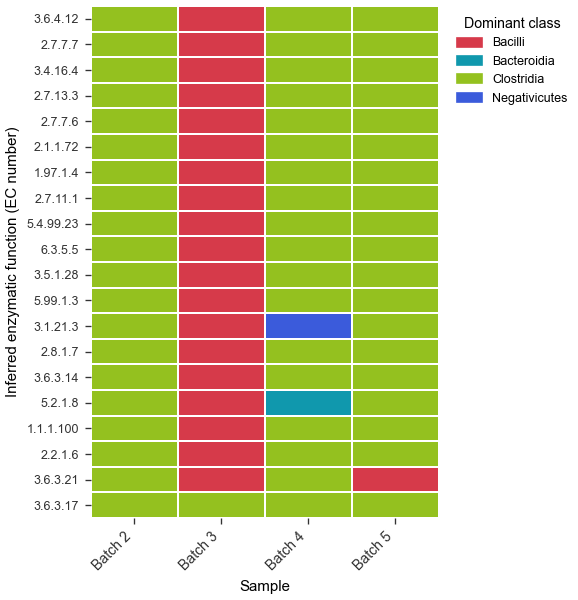

In [63]:
# =====================================================
# Figure 2B: Class-level function x sample comparison heatmap
# Cell color = dominant class; cell opacity = that class's share of the
# function's total inferred activity in that sample. Uses a GLOBAL top-20
# function list (summed across all samples), not each sample's own top-20,
# so every sample has a defined value for every row and the heatmap has
# no structural gaps from mismatched per-sample function selections.
# =====================================================

import matplotlib.colors as mcolors
import numpy as np

# ---- 1. GLOBAL top-20 functions, summed across ALL samples ----
global_top_functions = (
    ec_tax0.groupby("function")["taxon_rel_function_abun"]
    .sum().nlargest(20).index.tolist()
)

# ---- 2. Aggregate to (sample, function, class) using the FULL dataset,
#      restricted to the global top-20 -- not the per-sample-filtered table ----
df_heat = (
    ec_tax0[ec_tax0["function"].isin(global_top_functions)]
    .groupby(["sample", "function", "Taxon_class"], as_index=False)["norm_taxon_function_contrib"]
    .sum()
)

# ---- 3. For each (sample, function), find the dominant class and its share ----
def dominant_class_row(group):
    total = group["norm_taxon_function_contrib"].sum()
    if total == 0:
        return pd.Series({"dominant_class": None, "share": 0.0})
    top = group.loc[group["norm_taxon_function_contrib"].idxmax()]
    return pd.Series({"dominant_class": top["Taxon_class"], "share": top["norm_taxon_function_contrib"] / total})

dominant_per_cell = (
    df_heat.groupby(["sample", "function"])
    .apply(dominant_class_row)
    .reset_index()
)

# ---- 4. Row/sample order ----
function_order = (
    ec_tax0[ec_tax0["function"].isin(global_top_functions)]
    .groupby("function")["taxon_rel_function_abun"]
    .sum().sort_values(ascending=False).index.tolist()
)
order = [ "Batch 2","Batch 3", "Batch 4", "Batch 5"]  # explicit order for "the rest"

sample_order = [
    s for s in order if s in dominant_per_cell["sample"].unique()
]
# ---- 5. Build the RGBA matrix -- FLAT class color, no opacity encoding ----
n_func, n_samp = len(function_order), len(sample_order)
rgba_matrix = np.ones((n_func, n_samp, 4))
NO_DATA_RGBA = (0.92, 0.92, 0.92, 1.0)

func_idx = {f: i for i, f in enumerate(function_order)}
samp_idx = {s: i for i, s in enumerate(sample_order)}

has_data = np.zeros((n_func, n_samp), dtype=bool)

for _, row in dominant_per_cell.iterrows():
    if row["function"] not in func_idx or row["sample"] not in samp_idx:
        continue
    i, j = func_idx[row["function"]], samp_idx[row["sample"]]
    has_data[i, j] = True
    if row["dominant_class"] is None:
        rgba_matrix[i, j] = NO_DATA_RGBA
        continue
    rgb = mcolors.to_rgb(class_base_colors.get(row["dominant_class"], "#7f7f7f"))
    rgba_matrix[i, j] = (*rgb, 1.0)   # full opacity -- flat, solid class color

rgba_matrix[~has_data] = NO_DATA_RGBA
# ---- 6. Plot (no in-cell text) ----
fig, ax = plt.subplots(figsize=(FIGSIZE_HEATMAP[0] * 0.7, FIGSIZE_HEATMAP[1]))
ax.imshow(rgba_matrix, aspect="auto")

ax.set_xticks(range(n_samp))
ax.set_xticklabels(sample_order, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(n_func))
ax.set_yticklabels(function_order, fontsize=7.5)
ax.set_xlabel("Sample", fontsize=9)
ax.set_ylabel("Inferred enzymatic function (EC number)", fontsize=9)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, n_samp, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_func, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

present_classes = sorted(set(dominant_per_cell["dominant_class"].dropna()))
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=class_base_colors.get(c, "#7f7f7f"), label=c)
    for c in present_classes
]
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=class_base_colors.get(c, "#7f7f7f"), label=c)
    for c in present_classes
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left",
          title="Dominant class", fontsize=7.5, title_fontsize=8.5, frameon=False)
plt.tight_layout()
save_fig(fig_dir, "function_class_comparison_heatmap")
plt.show()

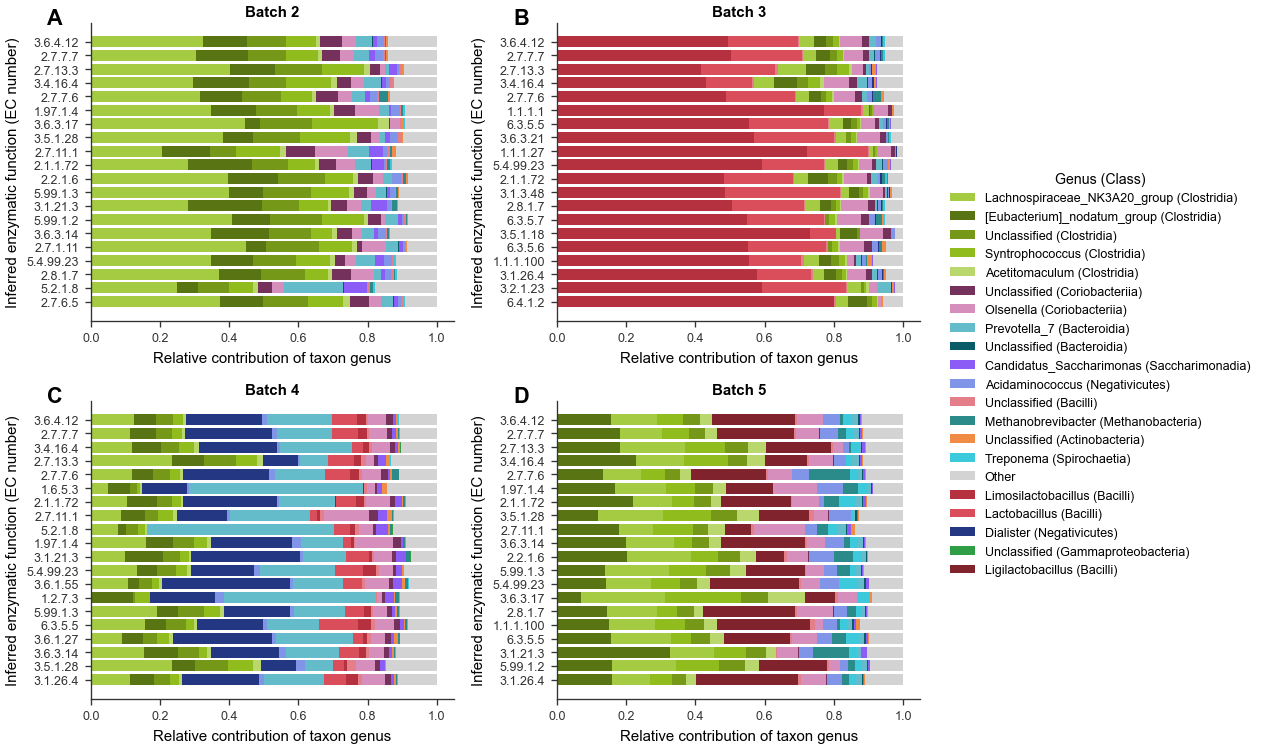

In [64]:
# ---- 10. Facet plot: all samples in one publication-ready figure ----
samples = df_filtered_top_functions["sample"].unique()
n_samples = len(samples)
n_cols = 2
n_rows = -(-n_samples // n_cols)  # ceiling division

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(FIGSIZE_BAR[0] * n_cols * 0.55, FIGSIZE_BAR[1] * n_rows * 0.75),
    squeeze=False,
)
axes_flat = axes.flatten()
panel_letters = [chr(ord("A") + i) for i in range(n_samples)]
all_handles, all_labels = {}, {}

for ax, s, letter in zip(axes_flat, samples, panel_letters):
    sub = df_filtered_top_functions[df_filtered_top_functions["sample"] == s]

    pivot = sub.pivot_table(
        index="function", columns="Taxon_genus_plot", values="rel",
        aggfunc="sum", fill_value=0
    )
    order = sub.groupby("function")["taxon_rel_function_abun"].sum().sort_values().index
    pivot = pivot.loc[order]

    plotted_genera = [g for g in pivot.columns if g != "Other"]
    genus_abun = sub.groupby("Taxon_genus_plot")["norm_taxon_function_contrib"].sum()

    genera_by_class = {}
    for g in plotted_genera:
        cls = g.split("Unclassified_", 1)[1] if g.startswith("Unclassified_") else genus_to_class.get(g, "Unclassified")
        genera_by_class.setdefault(cls, []).append(g)
    for cls in genera_by_class:
        genera_by_class[cls].sort(key=lambda g: genus_abun.get(g, 0), reverse=True)
    class_order = sorted(genera_by_class.keys(), key=lambda cls: genus_abun[genera_by_class[cls]].sum(), reverse=True)
    col_order = [g for cls in class_order for g in genera_by_class[cls]]
    if "Other" in pivot.columns:
        col_order.append("Other")
    pivot = pivot[col_order]

    display_labels = {g: genus_display_label(g) for g in pivot.columns}

    left = None
    for col in pivot.columns:
        bars = ax.barh(
            pivot.index, pivot[col], left=left,
            color=taxa_colors.get(col, "gray"),
            label=display_labels[col], height=0.8,
        )
        left = pivot[col] if left is None else left + pivot[col]
        if display_labels[col] not in all_labels:
            all_handles[display_labels[col]] = bars
            all_labels[display_labels[col]] = display_labels[col]

    ax.text(-0.12, 1.05, letter, transform=ax.transAxes,
             fontsize=13, fontweight="bold", va="top", ha="left")
    ax.set_xlabel("Relative contribution of taxon genus", fontsize=9)
    ax.set_ylabel("Inferred enzymatic function (EC number)", fontsize=9)
    ax.tick_params(axis="both", labelsize=7.5)
    ax.set_title(str(s), fontsize=9, fontweight="bold", pad=4)
    style_axes(ax)

for ax in axes_flat[n_samples:]:
    ax.set_visible(False)

fig.legend(
    all_handles.values(), all_labels.values(),
    loc="center left", bbox_to_anchor=(1.0, 0.5),
    title="Genus (Class)", fontsize=7.5, title_fontsize=8.5, frameon=False,
)

plt.tight_layout()
save_fig(fig_dir, "function_composition_facet")
plt.show()

## Map enzymes to bioproducts potential

We analyze the metabolic potential of these microbial communities beyond MCCAs. To do so, next, we create a dictionary with the main enzymes (EC numbers ) involved in pathways associated to the generation of additional bioproducts and metabolites different to carboxilic acids. 

In [65]:
# Bioproduct-EC dictionary

metabolic_capacities_broad_ec = {

    # ── GASES / REDOX ────────────────────────────────────────────────
    # Cleaned to genuine hydrogenases; dropped nitrogenase (H2 only as an
    # N2-fixation byproduct = different biology) and the legacy/duplicate
    # hydrogenase ECs. Added F420-reducing hydrogenase (methanogens in AD).
    "hydrogen_metabolism": [
        "1.12.1.2",   # NAD-reducing hydrogenase
        "1.12.7.2",   # ferredoxin hydrogenase ([FeFe])
        "1.12.5.1",   # hydrogen:quinone oxidoreductase (uptake)
        "1.12.2.1",   # cytochrome-c3 hydrogenase (Desulfovibrio-type)
        "1.12.98.1",  # coenzyme F420-reducing hydrogenase (methanogens)  
    ],

    # co2_release REMOVED: not a coherent function. CO2 is a byproduct of
    # hundreds of reactions; the previous decarboxylases (SAM-, phosphatidyl-
    # serine-, oxalate-decarboxylase) are not meaningful CO2 sources in AD.
    # A summed signal here tracks whatever unrelated decarboxylase is abundant.
    # If you must keep a CO2 proxy, use the real anaerobic nodes only:
    # "co2_release": [
    #     "1.2.7.1",   # pyruvate:ferredoxin oxidoreductase
    #     "1.2.1.2",   # formate dehydrogenase (formate -> CO2)
    #     "1.2.4.1",   # pyruvate dehydrogenase (E1)  
    # ],

    # ── CENTRAL FERMENTATION PRODUCTS (SCFAs) ────────────────────────
    # Trimmed to acetate-forming/committed steps; dropped generic aldehyde
    # DHs, ADH (ethanol node) and enoyl-CoA hydratase (chain elongation).
    "acetate": [
        "2.7.2.1",   # acetate kinase
        "2.3.1.8",   # phosphotransacetylase
        "6.2.1.1",   # acetyl-CoA synthetase
        "2.8.3.1",   # acetate CoA-transferase (broad specificity)
        "2.3.1.54",  # pyruvate formate-lyase (acetyl-CoA node)
        "1.2.7.1",   # pyruvate:ferredoxin oxidoreductase
    ],

    # Only the two diagnostic LDHs; removed glycolysis and lactaldehyde DH
    # (fucose/rhamnose catabolism, wrong pathway).
    "lactate": [
        "1.1.1.27",  # L-lactate dehydrogenase
        "1.1.1.28",  # D-lactate dehydrogenase
        "1.1.2.4",   # D-lactate dehydrogenase (quinone) -- lactate oxidation  # VERIFY relevance
    ],

    # Reductive-TCA branch to succinate; dropped GABA shunt, aconitase
    # (generic TCA) and the unconfirmed ECs. Label as succinate/reductive-TCA.
    "succinate": [
        "1.3.5.1",   # succinate dehydrogenase
        "1.3.5.4",   # fumarate reductase (quinol)
        "4.2.1.2",   # fumarate hydratase
        "1.1.1.37",  # malate dehydrogenase
        "6.2.1.5",   # succinyl-CoA synthetase
        "5.4.99.2",  # methylmalonyl-CoA mutase (propionate/succinate node)
    ],

    # ── ALCOHOLS / SOLVENTS ──────────────────────────────────────────
    # Committed ethanol steps only; dropped butanediol DH, generic aldehyde
    # DH, glycolysis and pta (acetate). AdhE covers 1.2.1.10 + 1.1.1.1.
    "ethanol": [
        "1.1.1.1",   # alcohol dehydrogenase
        "1.1.1.2",   # alcohol dehydrogenase (NADP+)
        "1.2.1.10",  # acetaldehyde dehydrogenase (acetylating)
        "4.1.1.1",   # pyruvate decarboxylase
    ],

    # Coherent as-is (Clostridial butanol/elongation); minor trim.
    "butanol": [
        "2.3.1.9",   # thiolase (acetyl-CoA C-acetyltransferase)
        "1.1.1.157", # 3-hydroxybutyryl-CoA dehydrogenase
        "4.2.1.17",  # crotonase (enoyl-CoA hydratase)
        "1.3.8.1",   # butyryl-CoA dehydrogenase
        "1.2.1.57",  # butanal dehydrogenase   
        "1.1.1.1",   # alcohol (butanol) dehydrogenase
    ],

    # ── LIPIDS / STORAGE ─────────────────────────────────────────────
    # RELABELED + rebuilt as genuine bacterial type-II FAS (was a mix of
    # synthesis + beta-oxidation). Removed type-I FAS 2.3.1.85 (eukaryotic),
    # the beta-oxidation ECs, NAD+ kinase and long-chain acyl-CoA ligase.
    "fatty_acid_biosynthesis": [
        "6.4.1.2",   # acetyl-CoA carboxylase (malonyl-CoA)
        "2.3.1.39",  # malonyl-CoA:ACP transacylase (FabD)
        "2.3.1.180", # 3-oxoacyl-ACP synthase III (FabH)
        "2.3.1.41",  # 3-oxoacyl-ACP synthase I (FabB)
        "2.3.1.179", # 3-oxoacyl-ACP synthase II (FabF)
        "1.1.1.100", # 3-oxoacyl-ACP reductase (FabG)
        "4.2.1.59",  # 3-hydroxyacyl-ACP dehydratase (FabZ)
        "1.3.1.9",   # enoyl-ACP reductase (FabI)
    ],

    # Trimmed to the three committed PHB steps (was padded with butanol/
    # chain-elongation enzymes). Fixed the missing-comma bug.
    "phb_biosynthesis": [
        "2.3.1.9",   # thiolase (PhaA)
        "1.1.1.36",  # acetoacetyl-CoA reductase (PhaB)
        "2.3.1.304", # PHB/PHA synthase (PhaC)  
    ],

    # ── SECONDARY METABOLISM ─────────────────────────────────────────
    # MEP/prenyl backbone only; dropped squalene monooxygenase (eukaryotic
    # sterol) and limonene synthase (plant) -- absent from prokaryotic data.
    "terpenoid_biosynthesis": [
        "1.1.1.267", # 1-deoxy-D-xylulose-5-P reductoisomerase (DXR/IspC)
        "1.17.7.1",  # HMBPP synthase (IspG)   
        "1.17.7.4",  # HMBPP reductase (IspH)
        "2.5.1.1",   # dimethylallyltranstransferase (GPP synthase)
        "2.5.1.10",  # farnesyl-PP synthase
        "2.5.1.29",  # geranylgeranyl-PP synthase
        "2.5.1.30",  # heptaprenyl-PP synthase
    ],

    # De-duplicated (4.2.1.10 was listed twice; dropped redundant 1.1.1.24).
    "shikimate": [
        "2.5.1.54",  # DAHP synthase
        "4.2.3.4",   # 3-dehydroquinate synthase
        "4.2.1.10",  # 3-dehydroquinate dehydratase
        "1.1.1.25",  # shikimate dehydrogenase
        "2.7.1.71",  # shikimate kinase
        "2.5.1.19",  # EPSP synthase
        "5.4.99.5",  # chorismate mutase
    ],

    # aromatics_degradation REMOVED for an anaerobic system: the previous ECs
    # are all aerobic, O2-dependent ring-cleavage enzymes (catechol di-
    # oxygenases, benzoate dioxygenase, salicylate/coumarate monooxygenases)
    # that are largely inoperative in AD. Anaerobic aromatic degradation runs
    # through benzoyl-CoA. If you keep the category, use that pathway instead:
    # "aromatics_degradation_anaerobic": [
    #     "6.2.1.25",  # benzoate-CoA ligase          # VERIFY
    #     "1.3.7.8",   # benzoyl-CoA reductase (ATP)   # VERIFY
    #     "1.3.7.9",   # benzoyl-CoA reductase (class II) # VERIFY
    # ],

    # ── CARBON FIXATION ──────────────────────────────────────────────
    # Focused on genuine fixation markers; dropped SDH/fumarase/ICDH (those
    # are TCA, already under succinate) and the unconfirmed ECs. Added CODH.
    "carbon_fixation": [
        "4.1.1.39",  # RuBisCO (CBB)
        "4.1.1.31",  # PEP carboxylase
        "1.2.7.1",   # pyruvate:ferredoxin oxidoreductase (rTCA/anaplerotic)
        "1.2.1.2",   # formate dehydrogenase (WL entry)
        "2.3.1.169", # CO-methylating acetyl-CoA synthase (Wood-Ljungdahl)
        "1.2.7.4",   # CO dehydrogenase, ferredoxin (Wood-Ljungdahl)  
    ],
}


In [66]:
# Signature-marker dictionary: only high-specificity, committed/diagnostic
# enzymes per category. Presence of the marker ~ capability for the function,
# so no pathway-completeness weighting is needed.
#
# NOTE ON DIRECTION: EC presence = capacity to run the reaction, not proof of
# net production (several markers are reversible). Report as "genetic potential."

metabolic_capacities_narrow_ec = {

    # ===== SPECIALIZED / DISCRIMINATING bioproducts =====
    # (patchily distributed -> these are the categories that separate samples)

    "hydrogen_metabolism": [        # H2-evolving hydrogenases (production direction)
        "1.12.7.2",   # ferredoxin hydrogenase ([FeFe], H2 evolution) -- primary marker
        "1.12.1.2",   # NAD-reducing hydrogenase
        "1.12.2.1",   # cytochrome-c3 hydrogenase (Desulfovibrio-type)
    ],

    "acetate": [                    # ackA-pta = the diagnostic acetate-formation pair
        "2.7.2.1",    # acetate kinase
        "2.3.1.8",    # phosphotransacetylase
    ],

    "lactate": [                    # LDH presence ~ lactate fermentation
        "1.1.1.27",   # L-lactate dehydrogenase
        "1.1.1.28",   # D-lactate dehydrogenase
    ],

    "succinate": [                  # only the specific production marker retained
        "1.3.5.4",    # fumarate reductase (quinol) -- anaerobic succinate formation
    ],

    "ethanol": [                    # committed ethanol-route markers (not plain ADH)
        "4.1.1.1",    # pyruvate decarboxylase
        "1.2.1.10",   # acetaldehyde dehydrogenase (acetylating) / AdhE route
    ],

    "butanol": [                    # butyryl-CoA elongation + terminal aldehyde step
        "1.1.1.157",  # 3-hydroxybutyryl-CoA dehydrogenase (hbd)
        "1.3.8.1",    # butyryl-CoA dehydrogenase (bcd)
        "1.2.1.57",   # butanal dehydrogenase (terminal)   
    ],

    "phb_biosynthesis": [           # PhaC is the definitive PHB marker
        "2.3.1.304",  # PHB/PHA synthase (PhaC)            
        "1.1.1.36",   # acetoacetyl-CoA reductase (PhaB)
    ],

    "carbon_fixation": [            # CBB + Wood-Ljungdahl autotrophy markers
        "4.1.1.39",   # RuBisCO (CBB)
        "2.3.1.169",  # CO-methylating acetyl-CoA synthase (Wood-Ljungdahl)
        "1.2.7.4",    # CO dehydrogenase, ferredoxin (Wood-Ljungdahl)   # VERIFY
    ],


    # ===== CORE / UNIVERSAL functions =====
    # Marker-specific but present in ~all taxa -> high, roughly constant
    # magnitude across samples; composition mirrors overall abundance.
    # Keep only if you want to show the function exists; they won't
    # differentiate inocula. Consider omitting from the comparison figure.

    "shikimate": [                  # committed entry/exit steps of the pathway
        "2.5.1.54",   # DAHP synthase (committed entry)
        "2.5.1.19",   # EPSP synthase (penultimate, committed)
        "5.4.99.5",   # chorismate mutase
    ],

    "fatty_acid_biosynthesis": [    # FAS-II signature (essential in bacteria)
        "2.3.1.180",  # 3-oxoacyl-ACP synthase III (FabH, initiation)   # VERIFY
        "2.3.1.179",  # 3-oxoacyl-ACP synthase II (FabF, elongation)
        "1.3.1.9",    # enoyl-ACP reductase (FabI)
    ],

    "terpenoid_biosynthesis": [     # MEP-pathway committed markers
        "1.1.1.267",  # DXP reductoisomerase (DXR/IspC, committed MEP step)
        "1.17.7.4",   # HMBPP reductase (IspH)
        "2.5.1.10",   # farnesyl-PP synthase (prenyl chain elongation)
    ],
}


Generate exact_map (exact matches) and wildcard_map (general matches corresponding to family)

## Figure 3: functional/bioproduct potential

/var/folders/yb/_xf4lxss6n9g0n8frp24vv7w0000gn/T/ipykernel_1064/3459148910.py:82: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2_bioproduct.groupby(["sample", "bioproduct"])["norm_taxon_function_contrib"]


Batch 2


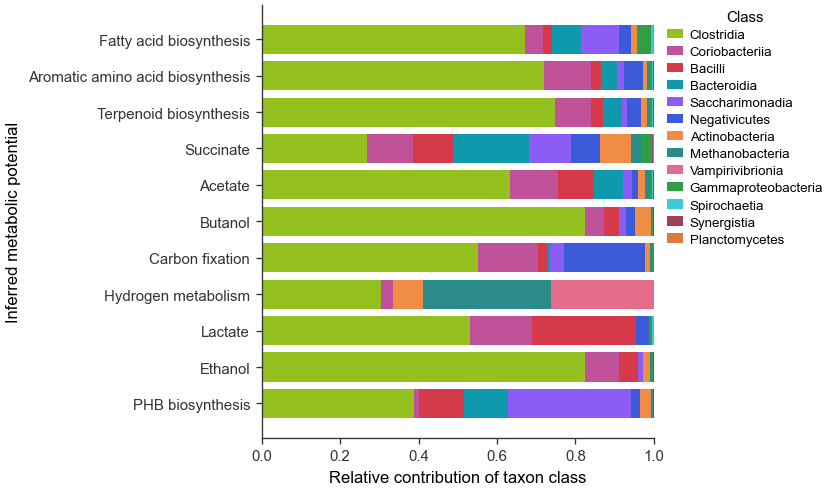

Batch 3


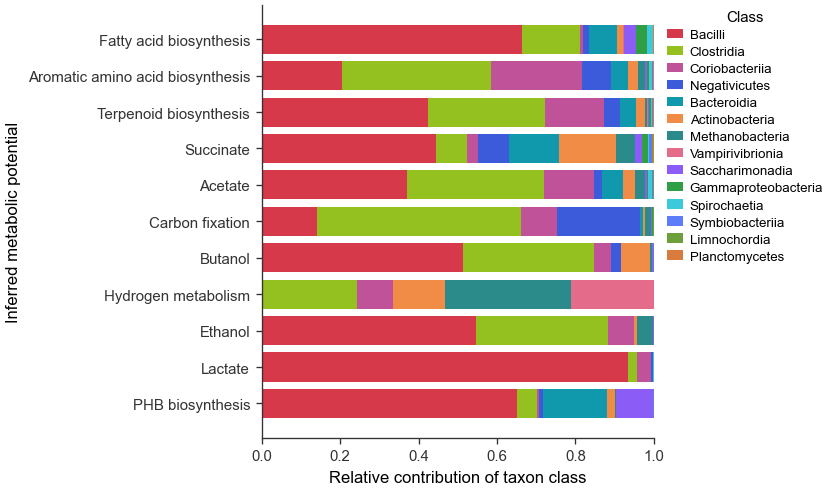

Batch 4


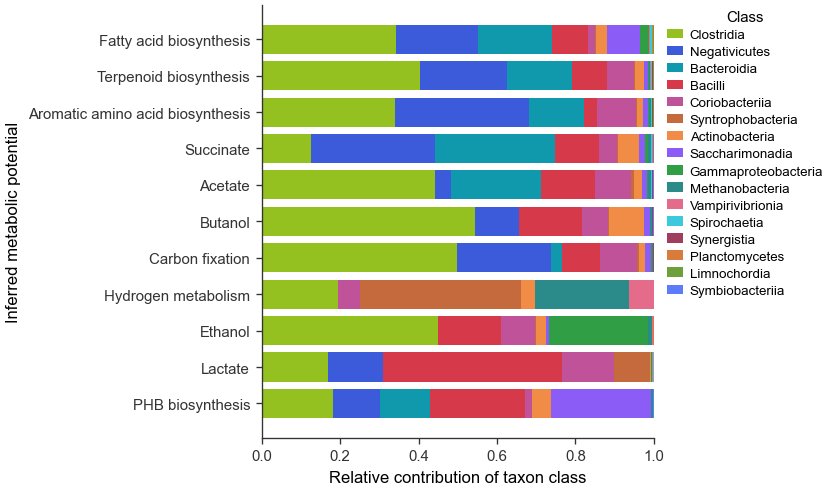

Batch 5


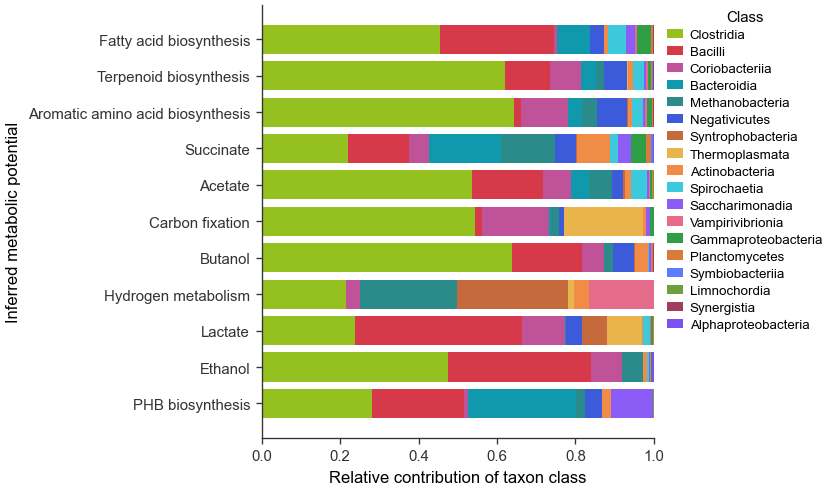

In [67]:
ec_tax2 = ec_tax0.copy()

# 1. Build EC. bioproduct maps

def build_ec_maps(metabolic_capacities_broad_ec):
    exact_map = defaultdict(list)
    wildcard_map = []
    for product, ec_list in metabolic_capacities_broad_ec.items():
        for ec in ec_list:
            if ec.endswith("."):
                wildcard_map.append((ec, product))
            else:
                exact_map[ec].append(product)
    return dict(exact_map), wildcard_map

exact_map, wildcard_map = build_ec_maps(metabolic_capacities_broad_ec)


# 2. Map EC → bioproduct

def map_ec_to_products(ec):
    products = set()
    if ec in exact_map:
        products.update(exact_map[ec])
    for prefix, product in wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

ec_tax2["bioproduct"] = ec_tax2["function"].apply(map_ec_to_products)

df_bp = (
    ec_tax2
    .explode("bioproduct")
    .dropna(subset=["bioproduct"])
    .copy()
)

bioproduct_display_labels = {
    "hydrogen_metabolism":      "Hydrogen metabolism",
    "lactate":                  "Lactate",
    "acetate":                  "Acetate",
    "succinate":                "Succinate",
    "ethanol":                  "Ethanol",
    "butanol":                  "Butanol",
    "fatty_acid_biosynthesis":  "Fatty acid biosynthesis",
    "phb_biosynthesis":         "PHB biosynthesis",
    "terpenoid_biosynthesis":   "Terpenoid biosynthesis",
    "shikimate":                "Aromatic amino acid biosynthesis",
    "carbon_fixation":          "Carbon fixation",
}


# 3. Filter noise

MIN_ABUN = 1e-4

df_bp = df_bp[df_bp["norm_taxon_function_contrib"] > MIN_ABUN].copy()


# 4. Bioproduct magnitude = summed PICRUSt2 predicted functional abundance
#    (norm_taxon_function_contrib; NO completeness weighting)

df2_bioproduct = df_bp.copy()


# Collapse to class-level plotting

df2_bioproduct["Taxon_plot"] = df2_bioproduct["Taxon_class"].fillna("Unclassified")

df2_bioproduct = (
    df2_bioproduct.groupby(["sample", "bioproduct", "Taxon_plot"], as_index=False)["norm_taxon_function_contrib"]
    .sum()
)


# 5. Top bioproducts (ranked by summed norm_taxon_function_contrib)

TOP_BP = 20

top_bp = (
    df2_bioproduct.groupby(["sample", "bioproduct"])["norm_taxon_function_contrib"]
    .sum()
    .reset_index()
    .groupby("sample", group_keys=False)
    .apply(lambda x: x.nlargest(TOP_BP, "norm_taxon_function_contrib"))
)

df2_bioproduct = df2_bioproduct.merge(
    top_bp[["sample", "bioproduct"]],
    on=["sample", "bioproduct"]
)


# 6. Relative abundance within each bioproduct (class contribution)

df2_bioproduct["rel"] = (
    df2_bioproduct.groupby(["sample", "bioproduct"])["norm_taxon_function_contrib"]
    .transform(lambda x: x / x.sum())
)


# 7. Ensure every class has a base color

_all_classes_here = [c for c in df2_bioproduct["Taxon_plot"].unique() if c != "Other"]
_missing_classes = [c for c in _all_classes_here if c not in class_base_colors]
if _missing_classes:
    print(f"Extending class_base_colors for previously-missing classes: {_missing_classes}")
    class_base_colors.update(build_class_base_colors(list(class_base_colors.keys()) + _missing_classes))

class_colors = {
    c: class_base_colors.get(c, "#d3d3d3")
    for c in df2_bioproduct["Taxon_plot"].unique()
}


# 8. Plot

samples = df2_bioproduct["sample"].unique()

for s in samples:

    print(s)

    sub = df2_bioproduct[df2_bioproduct["sample"] == s]

    pivot = sub.pivot_table(
        index="bioproduct",
        columns="Taxon_plot",
        values="rel",
        aggfunc="sum",
        fill_value=0
    )

    # ----------------------------------------------
    # Order bioproducts by summed predicted functional abundance
    # ----------------------------------------------

    order = (
    sub.groupby("bioproduct")["norm_taxon_function_contrib"]
    .sum()
    .sort_values(ascending=False)
    .index
    )

    pivot = pivot.loc[order[::-1]]
    pivot = pivot.rename(index=bioproduct_display_labels)  

    # ----------------------------------------------
    # Order classes by abundance within the figure
    # ----------------------------------------------

    class_abun = sub.groupby("Taxon_plot")["norm_taxon_function_contrib"].sum()
    class_order = sorted(
        class_abun.index,
        key=lambda c: class_abun[c],
        reverse=True,
    )

    pivot = pivot[class_order]

    fig = plt.figure(figsize=FIGSIZE_BAR)

    left = None

    for col in pivot.columns:
        plt.barh(
            pivot.index,
            pivot[col],
            left=left,
            color=class_colors.get(col, "lightgray"),
            label=col,
        )
        left = pivot[col] if left is None else left + pivot[col]

    plt.xlabel("Relative contribution of taxon class")
    plt.ylabel("Inferred metabolic potential")

    style_axes()

    dedupe_legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Class"
    )

    plt.tight_layout()

    save_fig(
        fig_dir,
        f"sample_{s}_bioproduct_composition"
    )

    plt.show()

## Facet plots general functions and bioproducts

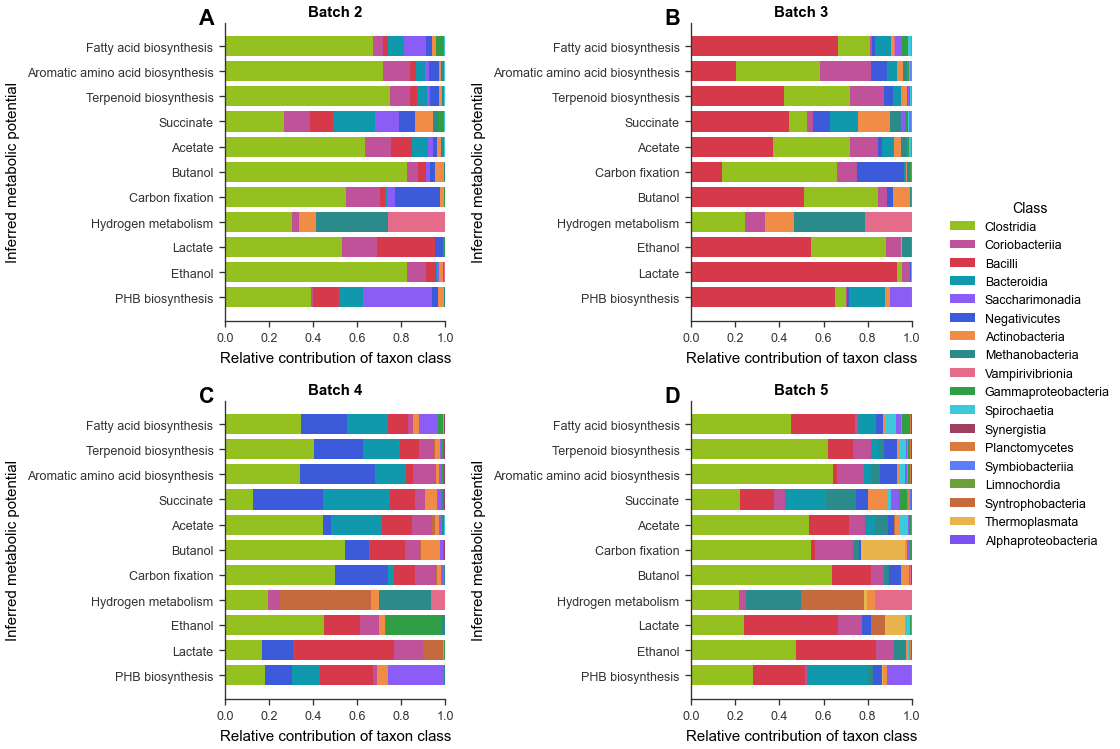

In [68]:
# =====================================================
# Figure 3 (FACET VERSION): general bioproduct composition by class
# All samples in one publication-ready figure, matching the style of
# the Figure 2 function facet and the Figure 4 carboxylic-acid facet.
# =====================================================

samples = df2_bioproduct["sample"].unique()
n_samples = len(samples)
n_cols = 2
n_rows = -(-n_samples // n_cols)  # ceiling division

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(FIGSIZE_BAR[0] * n_cols * 0.55, FIGSIZE_BAR[1] * n_rows * 0.75),
    squeeze=False,
)
axes_flat = axes.flatten()
panel_letters = [chr(ord("A") + i) for i in range(n_samples)]
all_handles, all_labels = {}, {}

for ax, s, letter in zip(axes_flat, samples, panel_letters):
    sub = df2_bioproduct[df2_bioproduct["sample"] == s]

    pivot = sub.pivot_table(
        index="bioproduct", columns="Taxon_plot", values="rel",
        aggfunc="sum", fill_value=0,
    )

    # Order bioproducts by summed predicted functional abundance
    order = (
        sub.groupby("bioproduct")["norm_taxon_function_contrib"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    pivot = pivot.loc[order[::-1]]
    pivot = pivot.rename(index=bioproduct_display_labels)

    # Order classes by abundance within this facet
    class_abun = sub.groupby("Taxon_plot")["norm_taxon_function_contrib"].sum()
    class_order = sorted(class_abun.index, key=lambda c: class_abun[c], reverse=True)
    pivot = pivot[class_order]

    left = None
    for col in pivot.columns:
        bars = ax.barh(
            pivot.index, pivot[col], left=left,
            color=class_colors.get(col, "lightgray"),
            label=col,
        )
        left = pivot[col] if left is None else left + pivot[col]
        if col not in all_labels:
            all_handles[col] = bars
            all_labels[col] = col

    # Panel letter, bold, top-left, Nature-style
    ax.text(
        -0.12, 1.05, letter, transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left"
    )

    ax.set_xlabel("Relative contribution of taxon class", fontsize=9)
    ax.set_ylabel("Inferred metabolic potential", fontsize=9)
    ax.tick_params(axis="both", labelsize=7.5)
    ax.set_title(str(s), fontsize=9, fontweight="bold", pad=4)
    style_axes(ax)

# Hide any unused subplot axes (if n_samples is odd for a 2-column grid)
for ax in axes_flat[n_samples:]:
    ax.set_visible(False)

# One shared, deduplicated legend for the whole figure
fig.legend(
    all_handles.values(), all_labels.values(),
    loc="center left", bbox_to_anchor=(1.0, 0.5),
    title="Class", fontsize=7.5, title_fontsize=8.5, frameon=False,
)

plt.tight_layout()
save_fig(fig_dir, "bioproduct_composition_facet")
plt.show()


# 3. Carboxilic acid -specific contributors

## Carboxylic-acid EC dictionary

Next, we create a dictionary with the main EC numbers (enzymes) involved in pathways associated with carboxilic acids chain elongation (including MCCAs). 

In [69]:
carboxylic_acid_ec = {

    "butyrate": [
        "2.3.1.9",    # acetyl-CoA C-acetyltransferase (thiolase)
        "2.3.1.16",   # acetyl-CoA C-acyltransferase (broader-specificity thiolase)
        "1.1.1.35",   # 3-hydroxyacyl-CoA dehydrogenase
        "1.1.1.36",   # acetoacetyl-CoA reductase
        "1.1.1.157",  # 3-hydroxybutyryl-CoA dehydrogenase
        "4.2.1.17",   # enoyl-CoA hydratase
        "4.2.1.55",   # 3-hydroxybutyryl-CoA dehydratase (crotonase)
        "1.3.8.1",    # butyryl-CoA dehydrogenase
        "1.3.8.7",    # medium-chain acyl-CoA dehydrogenase
        "2.8.3.9",    # butyrate-acetoacetate CoA-transferase
        "2.7.2.7",    # butyrate kinase
        "3.1.2.20",   # acyl-CoA hydrolase (medium-chain thioesterase)
        "2.3.1.8",    # phosphate acetyltransferase (phosphotransacetylase)
        "1.5.5.1",    # electron-transferring-flavoprotein dehydrogenase
        "1.18.1.3"    # ferredoxin-NADP+ reductase
    ],

    "valerate": [
        "2.3.1.9", "2.3.1.16",           # thiolases (see butyrate)
        "1.1.1.35", "1.1.1.36",          # hydroxyacyl-CoA DH / acetoacetyl-CoA reductase
        "4.2.1.17",                      # enoyl-CoA hydratase
        "1.3.8.1",                       # butyryl-CoA dehydrogenase
        "6.4.1.3",                       # propionyl-CoA carboxylase -- verified (odd-chain primer supply)
        "5.4.99.2",                      # methylmalonyl-CoA mutase -- verified (odd-chain primer supply)
        "1.3.1.31",                      # 2-enoate reductase -- CORRECTED LABEL (was mislabeled "odd-chain acyl-CoA DH" in earlier draft); its relevance to odd-chain elongation specifically is not yet independently confirmed, flag for review
        "2.8.3.1",                       # propionate CoA-transferase
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.3.1.8"                        # phosphotransacetylase
    ],

    "caproate": [
        "2.3.1.9", "2.3.1.16",           # thiolases
        "1.1.1.35", "1.1.1.36",          # hydroxyacyl-CoA DH / acetoacetyl-CoA reductase
        "4.2.1.17", "4.2.1.55",          # enoyl-CoA hydratase / dehydratase
        "1.3.8.7",                       # medium-chain acyl-CoA dehydrogenase
        "2.8.3.1",                       # propionate/acid CoA-transferase
        "2.8.3.8",                       # acetate CoA-transferase (broad specificity)
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.3.1.8",                       # phosphotransacetylase
        "1.5.5.1",                       # electron-transferring-flavoprotein dehydrogenase
        "1.18.1.3"                      # ferredoxin-NADP+ reductase
    ],

    "heptanoate": [
        "2.3.1.9", "2.3.1.16",           # thiolases
        "1.1.1.35",                      # 3-hydroxyacyl-CoA dehydrogenase
        "4.2.1.17",                      # enoyl-CoA hydratase
        "1.3.8.1",                       # butyryl-CoA dehydrogenase
        "6.4.1.3",                       # propionyl-CoA carboxylase -- verified (odd-chain primer supply)
        "5.4.99.2",                      # methylmalonyl-CoA mutase -- verified (odd-chain primer supply)
        "1.3.1.31",                      # 2-enoate reductase -- CORRECTED LABEL, flag for review (see valerate note)
        "2.8.3.1",                       # propionate CoA-transferase
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.3.1.8"                        # phosphotransacetylase
    ],

    "caprylate": [
        "2.3.1.9", "2.3.1.16",           # thiolases
        "1.1.1.35", "1.1.1.36",          # hydroxyacyl-CoA DH / acetoacetyl-CoA reductase
        "4.2.1.17", "4.2.1.55",          # enoyl-CoA hydratase / dehydratase
        "1.3.8.7",                       # medium-chain acyl-CoA dehydrogenase
        "2.8.3.1", "2.8.3.8",            # CoA-transferases
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.3.1.8",                       # phosphotransacetylase
        "1.5.5.1", "1.18.1.3",           # redox support (ETF-DH, ferredoxin-NADP+ reductase)
    ],

    "isobutyrate": [
        "2.6.1.42",                      # branched-chain amino acid aminotransferase
        "1.2.4.4",                       # 3-methyl-2-oxobutanoate dehydrogenase, E1 (lipoamide)
        "2.3.1.168",                     # dihydrolipoyllysine-residue (2-methylpropanoyl)transferase, E2 -- verified
        "1.8.1.4",                       # dihydrolipoyl dehydrogenase, E3
        "1.3.8.1", "1.3.8.7",            # isobutyryl-CoA / short-chain acyl-CoA dehydrogenase
        "4.2.1.17",                      # enoyl-CoA hydratase
        "2.8.3.1", "2.8.3.8", "2.8.3.9", # broad-specificity CoA-transferases
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.7.2.15"                       # propionate/butyrate/isobutyrate kinase
    ],

    "isovalerate": [
        "2.6.1.42",                      # branched-chain amino acid aminotransferase
        "1.2.4.4",                       # 3-methyl-2-oxobutanoate dehydrogenase, E1
        "2.3.1.168",                     # dihydrolipoyllysine-residue (2-methylpropanoyl)transferase, E2 -- also handles leucine-derived acyl groups; verified
        "1.8.1.4",                       # dihydrolipoyl dehydrogenase, E3
        "1.3.8.4",                       # isovaleryl-CoA dehydrogenase
        "6.4.1.4",                       # 3-methylcrotonyl-CoA carboxylase
        "4.2.1.18",                      # methylglutaconyl-CoA hydratase
        "2.8.3.1", "2.8.3.9",            # CoA-transferases
        "3.1.2.20",                      # acyl-CoA hydrolase
        "2.7.2.15",                      # acid kinase
        "2.3.1.19"                       # phosphate butyryltransferase -- verified: highest relative activity with butyryl-, isovaleryl-, valeryl-CoA
    ],

    "propionate": [
        # Succinate (dicarboxylic acid) pathway
        "2.3.1.54",                      # pyruvate formate-lyase (formate C-acetyltransferase)
        "4.1.1.31",                      # phosphoenolpyruvate carboxylase
        "1.1.1.37",                      # malate dehydrogenase
        "4.2.1.2",                       # fumarate hydratase (fumarase)
        "1.3.5.1",                       # succinate dehydrogenase -- CONSOLIDATED here from deprecated 1.3.5.4 (fumarate reductase, quinol); 1.3.5.4 was correct in content but officially deleted/merged into 1.3.5.1 by IUBMB in 2022
        "2.8.3.18",                      # succinyl-CoA:acetate CoA-transferase -- verified; BRENDA notes it also carries propanoyl-CoA:succinate CoA-transferase activity in some organisms, directly reinforcing relevance here
        "5.1.99.1",                      # methylmalonyl-CoA epimerase -- verified
        "5.4.99.2",                      # methylmalonyl-CoA mutase -- verified, corrected from earlier draft's 5.4.99.1 (which is methylaspartate mutase, an unrelated enzyme)
        "4.1.1.41",                      # methylmalonyl-CoA decarboxylase

        # Acrylate pathway
        "1.1.1.27",                      # lactate dehydrogenase
        "2.8.3.1",                       # propionate CoA-transferase (lactate-CoA transfer)
        "4.2.1.54",                      # lactoyl-CoA dehydratase
        "1.3.8.1",                       # acrylyl-CoA reductase

        # Terminal formation
        "2.8.3.8",                       # acetate/propionate CoA-transferase
        "2.7.2.15",                      # propionate kinase
        "2.3.1.8",                       # phosphotransacetylase
        "2.7.2.1"                        # acetate kinase
    ]
}

## Figure 4: Carboxilic acid metabolic potential and taxon contribution

24 genera exceed 20% contribution in at least one sample-bioproduct cell, WITHIN their own primer group:
  V3-V4: ['Acidaminococcus', 'Anaerococcus', 'Bacillus', 'Candidatus_Saccharimonas', 'Dialister', 'Family_XIII_AD3011_group', 'Lachnospiraceae_NK3A20_group', 'Lactobacillus', 'Ligilactobacillus', 'Limosilactobacillus', 'Megasphaera', 'Methanobrevibacter', 'NK4A214_group', 'Olsenella', 'Peptoniphilus', 'Prevotella', 'Prevotella_7', 'Saccharopolyspora', 'Syntrophobacter', 'Thermoactinomyces', 'Thermopolyspora', 'Unclassified', '[Eubacterium]_coprostanoligenes_group', '[Eubacterium]_nodatum_group']


/var/folders/yb/_xf4lxss6n9g0n8frp24vv7w0000gn/T/ipykernel_1064/3622076533.py:150: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2_mcca.groupby(["sample", "mcca_bioproduct"])["norm_taxon_function_contrib"]


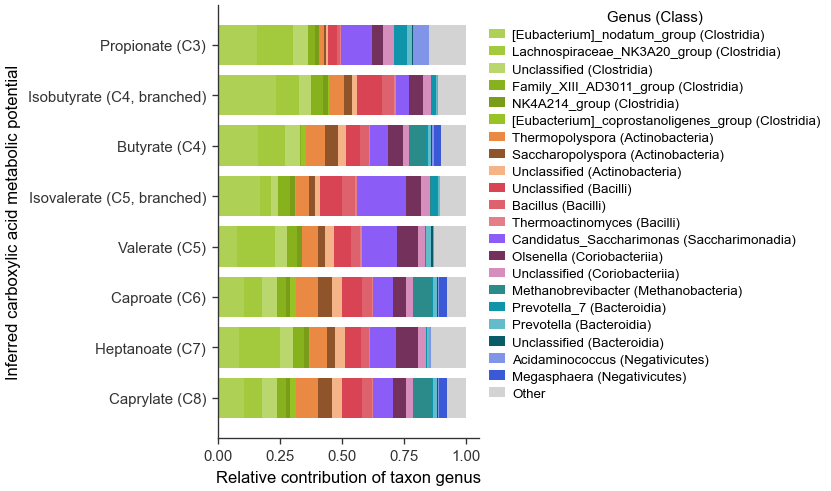

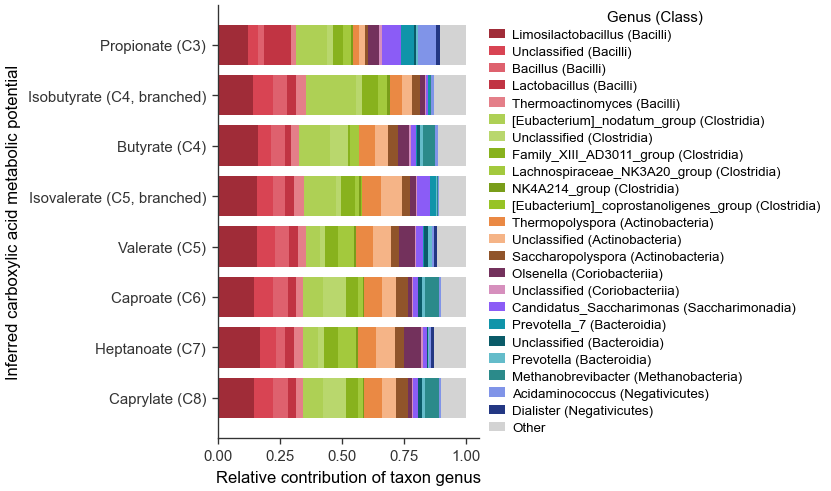

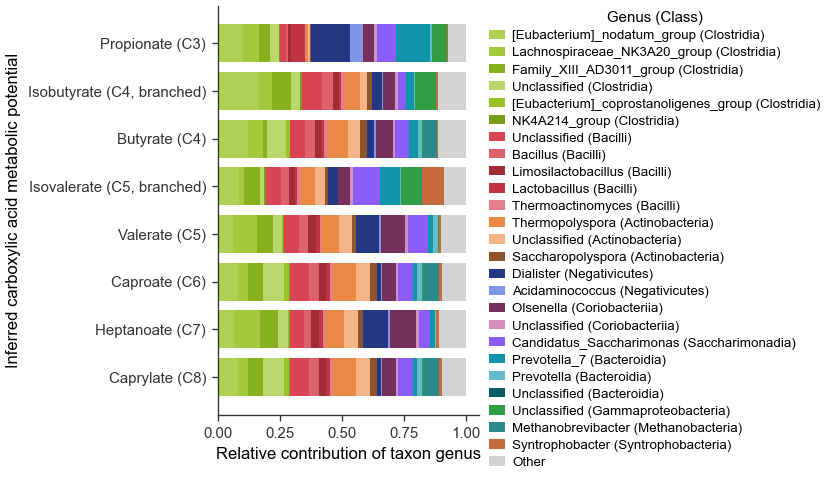

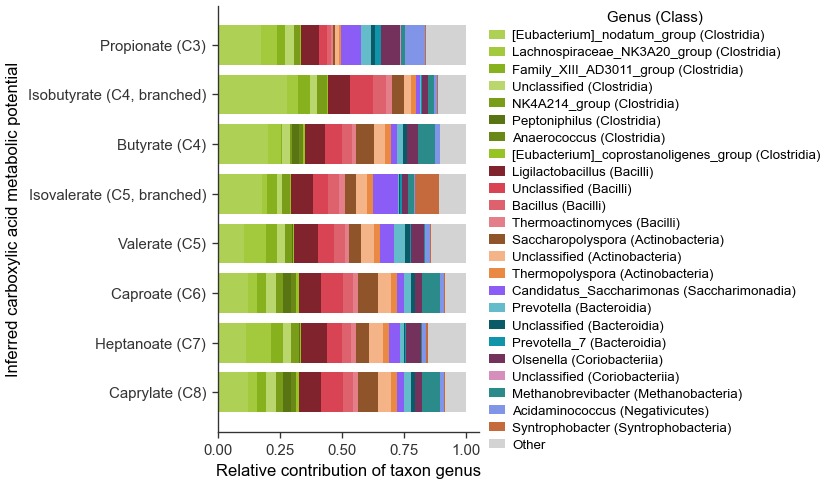

In [70]:
# Function to build FAST EC → bioproduct mapping


def build_ec_maps(carboxylic_acid_ec):
    exact_map = defaultdict(list)
    wildcard_map = []

    for product, ec_list in carboxylic_acid_ec.items():
        for ec in ec_list:
            if ec.endswith("."):
                wildcard_map.append((ec, product)) # map families, not exact matches
            else:
                exact_map[ec].append(product)

    return dict(exact_map), wildcard_map


# EC → MCCA bioproduct mapping (dictionary unchanged from yours)

exact_map, wildcard_map = build_ec_maps(carboxylic_acid_ec)

def map_ec_to_products(ec):
    products = set()
    if ec in exact_map:
        products.update(exact_map[ec])
    for prefix, product in wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

ec_tax2 = ec_tax0.copy()
ec_tax2["mcca_bioproduct"] = ec_tax2["function"].apply(map_ec_to_products)
df_mcca_bp = ec_tax2.explode("mcca_bioproduct").dropna(subset=["mcca_bioproduct"]).copy()


# 3. Filter noise

MIN_ABUN = 1e-4
df_mcca_bp = df_mcca_bp[df_mcca_bp["norm_taxon_function_contrib"] > MIN_ABUN].copy()


# 4. Bioproduct magnitude = summed PICRUSt2 predicted functional abundance
#    (norm_taxon_function_contrib; NO completeness weighting -- carboxylic_acid_ec's
#    categories share extensive, pervasive EC overlap, e.g. caproate/caprylate
#    are 100% identical and valerate/heptanoate 92-100%, so a per-category
#    completeness fraction would not measure independent pathway presence)

df2_mcca = df_mcca_bp.copy()


# Genus selection: threshold applied PER PRIMER GROUP, not pooled across
# all samples. A genus qualifies for a primer group if it clears
# ABUNDANCE_THRESHOLD in at least one (sample, mcca_bioproduct) cell
# WITHIN that group; once qualified, its real value is shown in every
# sample of that SAME group (never borrowed across groups). See Figure 1
# for the full rationale.

ABUNDANCE_THRESHOLD = 0.2   # 20% -- norm_taxon_function_contrib is bounded to [0,1]

primer_group_map = {
    "Rumen": "V1-V2", "Wine": "V1-V2",
    "R80W20": "V6-V8", "R50W50": "V6-V8", "R20W80": "V6-V8",
    "Batch 2": "V3-V4", "Batch 3": "V3-V4", "Batch 4": "V3-V4", "Batch 5": "V3-V4",
}

df2_mcca["primer_group"] = df2_mcca["sample"].map(primer_group_map)

_unmapped = df2_mcca.loc[df2_mcca["primer_group"].isna(), "sample"].unique()
if len(_unmapped) > 0:
    print(f"WARNING: these samples have no primer_group mapping and will be "
          f"excluded from genus qualification: {list(_unmapped)}")

max_contrib_per_genus_per_group = (
    df2_mcca.groupby(["primer_group", "Taxon_genus"])["norm_taxon_function_contrib"]
    .max()
)

plotted_genera_final = set(
    max_contrib_per_genus_per_group[max_contrib_per_genus_per_group >= ABUNDANCE_THRESHOLD]
    .index.get_level_values("Taxon_genus")
)

print(f"{len(plotted_genera_final)} genera exceed {ABUNDANCE_THRESHOLD:.0%} "
      f"contribution in at least one sample-bioproduct cell, WITHIN their own primer group:")
for pg in df2_mcca["primer_group"].dropna().unique():
    qualifying_here = max_contrib_per_genus_per_group[pg][max_contrib_per_genus_per_group[pg] >= ABUNDANCE_THRESHOLD]
    print(f"  {pg}: {list(qualifying_here.index)}")

df2_mcca["Taxon_genus_plot"] = (
    df2_mcca["Taxon_genus"]
    .where(df2_mcca["Taxon_genus"].isin(plotted_genera_final), "Other")
)
df2_mcca = df2_mcca.drop(columns=["primer_group"])

# Robust renaming of Unclassified genera
# (MUST happen BEFORE aggregation)

def plot_key_robust(row):

    g = row["Taxon_genus_plot"]

    if g == "Other":
        return "Other"

    if g == "Unclassified":
        cls = (
            row["Taxon_class"]
            if pd.notna(row["Taxon_class"])
            else "Unclassified"
        )
        return f"Unclassified_{cls}"

    return g


df2_mcca["Taxon_genus_plot"] = (
    df2_mcca.apply(plot_key_robust, axis=1)
)

# Merge THIS figure's genus set into the shared master taxa_colors -- this
# step was previously MISSING, which is why genera fell back to gray even
# though plot_key_robust correctly re-keyed them. Uses each genus's own
# class (parsed from "Unclassified_<Class>" where applicable, or looked
# up via genus_to_class for ordinary genus names).
_genera_here = [g for g in df2_mcca["Taxon_genus_plot"].unique() if g != "Other"]
_genera_by_class_here = {}
for g in _genera_here:
    if g.startswith("Unclassified_"):
        cls = g.split("Unclassified_", 1)[1]
    else:
        cls = genus_to_class.get(g, "Unclassified")
    _genera_by_class_here.setdefault(cls, []).append(g)

_missing_classes = [c for c in _genera_by_class_here if c not in class_base_colors]
if _missing_classes:
    print(f"Extending class_base_colors for previously-missing classes: {_missing_classes}")
    class_base_colors.update(build_class_base_colors(list(class_base_colors.keys()) + _missing_classes))

taxa_colors.update(get_genus_colors(_genera_by_class_here, class_base_colors))

_still_gray = [g for g in _genera_here if taxa_colors.get(g) in ("#7f7f7f", "lightgray", "#d3d3d3")]
if _still_gray:
    print(f"WARNING: these genera are STILL gray after the fix -- investigate further: {_still_gray}")

# 5. Top bioproducts (ranked by summed norm_taxon_function_contrib)

TOP_BP = 20

top_bp = (
    df2_mcca.groupby(["sample", "mcca_bioproduct"])["norm_taxon_function_contrib"]
    .sum()
    .reset_index()
    .groupby("sample", group_keys=False)
    .apply(lambda x: x.nlargest(TOP_BP, "norm_taxon_function_contrib"))
)

df2_mcca = df2_mcca.merge(
    top_bp[["sample", "mcca_bioproduct"]],
    on=["sample", "mcca_bioproduct"]
)

# Collapse rows AFTER renaming

df2_mcca = (
    df2_mcca
    .groupby(
        [
            "sample",
            "mcca_bioproduct",
            "Taxon_genus_plot"
        ],
        as_index=False
    )
    .agg(
        norm_taxon_function_contrib=(
            "norm_taxon_function_contrib",
            "sum"
        )
    )
)

# Relative abundances (bars sum to 1)

df2_mcca["rel"] = (
    df2_mcca.groupby(["sample", "mcca_bioproduct"])["norm_taxon_function_contrib"]
    .transform(lambda x: x / x.sum())
)

# Legend labels

def genus_display_label(g):
    if g == "Other":
        return "Other"
    if g.startswith("Unclassified_"):
        return f"Unclassified ({g.split('Unclassified_',1)[1]})"
    return f"{g} ({genus_to_class.get(g,'Unclassified')})"

# Plot per sample

carbon_chain_order = [
    "propionate",
    "isobutyrate",
    "butyrate",
    "isovalerate",
    "valerate",
    "caproate",
    "heptanoate",
    "caprylate"
]

samples = df2_mcca["sample"].unique()

for s in samples:

    sub = df2_mcca[df2_mcca["sample"] == s]

    pivot = sub.pivot_table(
        index="mcca_bioproduct",
        columns="Taxon_genus_plot",
        values="rel",
        aggfunc="sum",
        fill_value=0,
    )

    # ---------------------------------------------
    # Order MCCA products 
    # ---------------------------------------------

    carboxylic_acid_display_labels = {
    "propionate":   "Propionate (C3)",
    "isobutyrate":  "Isobutyrate (C4, branched)",
    "butyrate":     "Butyrate (C4)",
    "isovalerate":  "Isovalerate (C5, branched)",
    "valerate":     "Valerate (C5)",
    "caproate":     "Caproate (C6)",
    "heptanoate":   "Heptanoate (C7)",
    "caprylate":    "Caprylate (C8)",
    }

    order = [bp for bp in carbon_chain_order if bp in pivot.index]
    pivot = pivot.loc[order[::-1]]
    pivot = pivot.rename(index=carboxylic_acid_display_labels)   

    # ---------------------------------------------
    # Order genera by class
    # ---------------------------------------------

    plotted_genera = [
        g for g in pivot.columns
        if g != "Other"
    ]

    genus_abun = (
        sub.groupby("Taxon_genus_plot")["norm_taxon_function_contrib"]
        .sum()
    )

    genera_by_class = {}

    for g in plotted_genera:

        if g.startswith("Unclassified_"):
            cls = g.split("Unclassified_", 1)[1]
        else:
            cls = genus_to_class.get(g, "Unclassified")

        genera_by_class.setdefault(cls, []).append(g)

    # Order genera within each class
    for cls in genera_by_class:

        genera_by_class[cls].sort(
            key=lambda g: genus_abun.get(g, 0),
            reverse=True
        )

    # Order classes by total abundance
    class_order = sorted(
        genera_by_class.keys(),
        key=lambda cls: sum(genus_abun.get(g, 0) for g in genera_by_class[cls]),
        reverse=True
    )

    col_order = [
        g
        for cls in class_order
        for g in genera_by_class[cls]
    ]

    if "Other" in pivot.columns:
        col_order.append("Other")

    pivot = pivot[col_order]

    # ---------------------------------------------
    # Plot
    # ---------------------------------------------

    display_labels = {
        g: genus_display_label(g)
        for g in pivot.columns
    }

    fig = plt.figure(figsize=FIGSIZE_BAR)

    left = None

    for col in pivot.columns:

        plt.barh(
            pivot.index,
            pivot[col],
            left=left,
            color=taxa_colors.get(col, "lightgray"),
            label=display_labels[col],
        )

        left = pivot[col] if left is None else left + pivot[col]

    plt.xlabel("Relative contribution of taxon genus")
    plt.ylabel("Inferred carboxylic acid metabolic potential")

    style_axes()

    dedupe_legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Genus (Class)",
    )

    plt.tight_layout()

    save_fig(
        fig_dir,
        f"sample_{s}_mcca_bioproduct_composition",
    )

    plt.show()

## Facet plot: carboxyloic acids

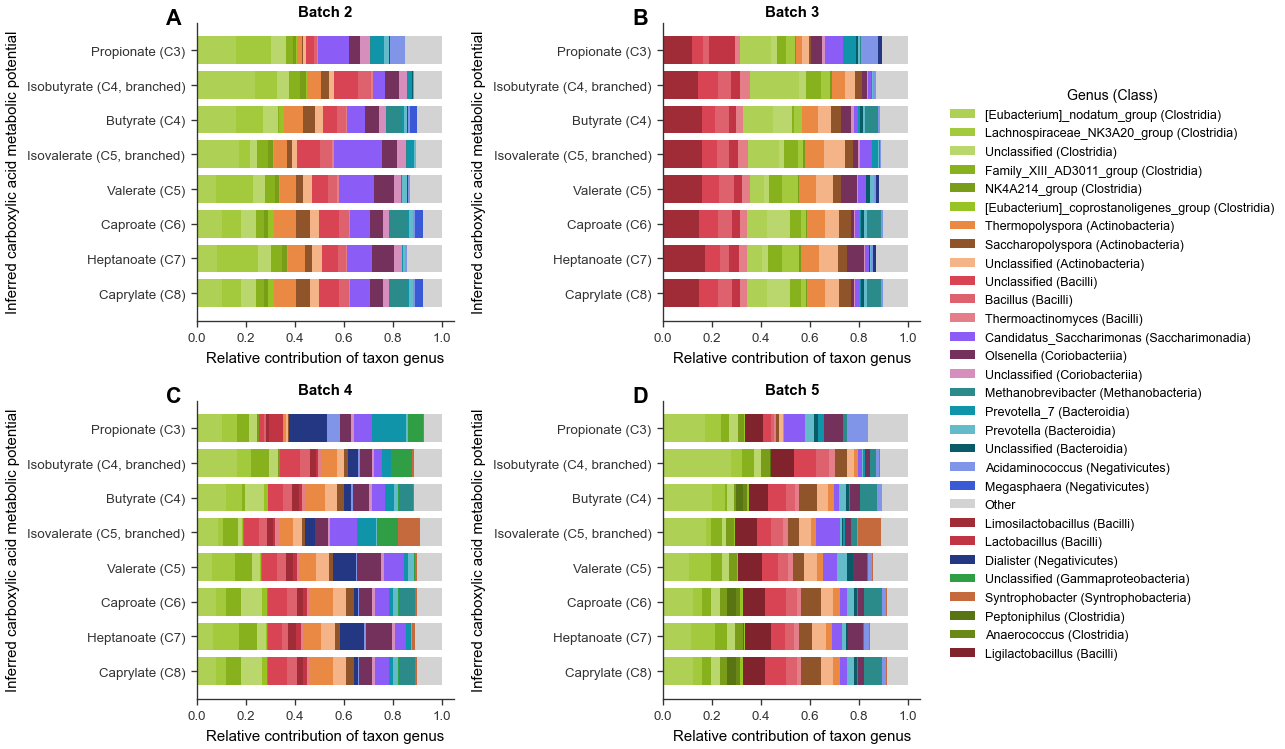

In [71]:
# ---------------------------------------------
# Facet plot: all samples in one publication-ready figure
# ---------------------------------------------

carboxylic_acid_display_labels = {
    "propionate":   "Propionate (C3)",
    "isobutyrate":  "Isobutyrate (C4, branched)",
    "butyrate":     "Butyrate (C4)",
    "isovalerate":  "Isovalerate (C5, branched)",
    "valerate":     "Valerate (C5)",
    "caproate":     "Caproate (C6)",
    "heptanoate":   "Heptanoate (C7)",
    "caprylate":    "Caprylate (C8)",
}

samples = df2_mcca["sample"].unique()
n_samples = len(samples)
n_cols = 2
n_rows = -(-n_samples // n_cols)  # ceiling division

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(FIGSIZE_BAR[0] * n_cols * 0.55, FIGSIZE_BAR[1] * n_rows * 0.75),
    squeeze=False,
)
axes_flat = axes.flatten()
panel_letters = [chr(ord("A") + i) for i in range(n_samples)]
all_handles, all_labels = {}, {}

for ax, s, letter in zip(axes_flat, samples, panel_letters):
    sub = df2_mcca[df2_mcca["sample"] == s]

    pivot = sub.pivot_table(
        index="mcca_bioproduct", columns="Taxon_genus_plot", values="rel",
        aggfunc="sum", fill_value=0,
    )

    # Order MCCA products by carbon chain length
    order = [bp for bp in carbon_chain_order if bp in pivot.index]
    pivot = pivot.loc[order[::-1]]
    pivot = pivot.rename(index=carboxylic_acid_display_labels)

    # Order genera by class
    plotted_genera = [g for g in pivot.columns if g != "Other"]
    genus_abun = sub.groupby("Taxon_genus_plot")["norm_taxon_function_contrib"].sum()

    genera_by_class = {}
    for g in plotted_genera:
        cls = g.split("Unclassified_", 1)[1] if g.startswith("Unclassified_") else genus_to_class.get(g, "Unclassified")
        genera_by_class.setdefault(cls, []).append(g)
    for cls in genera_by_class:
        genera_by_class[cls].sort(key=lambda g: genus_abun.get(g, 0), reverse=True)

    class_order = sorted(
        genera_by_class.keys(),
        key=lambda cls: sum(genus_abun.get(g, 0) for g in genera_by_class[cls]),
        reverse=True
    )

    col_order = [g for cls in class_order for g in genera_by_class[cls]]
    if "Other" in pivot.columns:
        col_order.append("Other")
    pivot = pivot[col_order]

    display_labels = {g: genus_display_label(g) for g in pivot.columns}

    left = None
    for col in pivot.columns:
        bars = ax.barh(
            pivot.index, pivot[col], left=left,
            color=taxa_colors.get(col, "lightgray"),
            label=display_labels[col],
        )
        left = pivot[col] if left is None else left + pivot[col]
        if display_labels[col] not in all_labels:
            all_handles[display_labels[col]] = bars
            all_labels[display_labels[col]] = display_labels[col]

    # Panel letter, bold, top-left, Nature-style
    ax.text(
        -0.12, 1.05, letter, transform=ax.transAxes,
        fontsize=13, fontweight="bold", va="top", ha="left"
    )

    ax.set_xlabel("Relative contribution of taxon genus", fontsize=9)
    ax.set_ylabel("Inferred carboxylic acid metabolic potential", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_title(str(s), fontsize=9, fontweight="bold", pad=4)
    style_axes(ax)

# Hide any unused subplot axes (if n_samples is odd for a 2-column grid)
for ax in axes_flat[n_samples:]:
    ax.set_visible(False)

# One shared, deduplicated legend for the whole figure
fig.legend(
    all_handles.values(), all_labels.values(),
    loc="center left", bbox_to_anchor=(1.0, 0.5),
    title="Genus (Class)", fontsize=7.5, title_fontsize=8.5, frameon=False,
)

plt.tight_layout()
save_fig(fig_dir, "carboxylic_acid_potential_facet")
plt.show()

# 4. Ordenance CLR + PCA

## Figure 5: Ordenance CLR + PCA

This figure converts relative abundances from 16S amplicon sequencing to Centralized Logaritmic Ratio (CLR) values and reduces dimensinoality, allowing comparing the diversity of the different batch stages similar to what it could have been achieved through beta diversity measurements. In other words, it is an Aitchison-space ordination — genus level
 

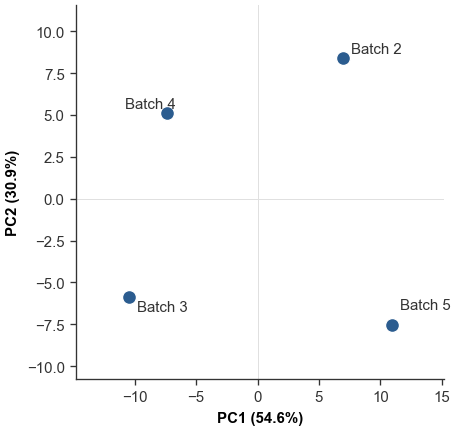

In [72]:
from sklearn.decomposition import PCA

# 1. Build genus x sample count table (use taxon_abun, summed to genus)
genus_tab = (
    ec_tax0.groupby(["sample", "Taxon_genus"])["taxon_abun"]
    .sum().reset_index()
    .pivot_table(index="sample", columns="Taxon_genus", values="taxon_abun", fill_value=0)
)

# 2. Bayesian multiplicative zero replacement (CLR can't take log(0))
#    Simple, dependency-free version: replace zeros with a small fraction
#    of the smallest observed value, then re-close (rows sum to 1).
def multiplicative_replacement(mat, delta=None):
    mat = mat.astype(float).values
    # convert to proportions
    props = mat / mat.sum(axis=1, keepdims=True)
    if delta is None:
        # small pseudo-count relative to detection limit
        delta = np.min(props[props > 0]) * 0.65
    zero_mask = props == 0
    n_zeros = zero_mask.sum(axis=1, keepdims=True)
    props_repl = np.where(zero_mask, delta, props * (1 - n_zeros * delta))
    return props_repl

props = multiplicative_replacement(genus_tab)

# 3. CLR transform
def clr(props):
    logp = np.log(props)
    return logp - logp.mean(axis=1, keepdims=True)

clr_mat = clr(props)
clr_df = pd.DataFrame(clr_mat, index=genus_tab.index, columns=genus_tab.columns)

# 4. PCA (n_components capped at n_samples - 1)
n_comp = min(3, clr_df.shape[0] - 1)
pca = PCA(n_components=n_comp)
scores = pca.fit_transform(clr_df.values)
var_exp = pca.explained_variance_ratio_ * 100

# 5. Plot PC1 vs PC2, samples labeled, connected in order for SBR trajectory
# Font/rcParams are already set globally in the "Publication style" cell above;
# reuse the shared FIGSIZE_PCA constant so this panel is sized consistently
# with the rest of the figure set.
fig = plt.figure(figsize=FIGSIZE_PCA)

# 6. Plot the PCA scores
# We use a clean, sophisticated color with a white stroke outline for contrast
plt.scatter(
    scores[:, 0], scores[:, 1], 
    s=70,                       # Scaled down to match smaller figure size
    color='#2b5c8f',            # Elegant deep slate blue
    edgecolors='white',         # High contrast ring
    linewidths=0.8, 
    zorder=3
)
ax = plt.gca()
ax.margins(0.2)   # 20% padding on all sides so offset labels have room
# 7. Refined text annotations -- cycle offsets so adjacent labels don't stack
sample_labels = clr_df.index.tolist()
offsets = [(5, 3), (5, -8), (-25, 3), (5, 10), (-30, -8)]
for i, name in enumerate(sample_labels):
    dx, dy = offsets[i % len(offsets)]
    plt.annotate(
        name, (scores[i, 0], scores[i, 1]),
        textcoords="offset points", xytext=(dx, dy),
        fontsize=9, color='#333333'
    )

# 8. Subtle trajectory line for SBR
if DATASET == "SBR":
    order = [s for s in ["SVR2", "SVR3", "SVR5", "SVR6"] if s in sample_labels]
    idx = [sample_labels.index(s) for s in order]
    plt.plot(
        scores[idx, 0], scores[idx, 1], 
        linestyle="--",         # Dashed line looks more intentional than solid gray
        linewidth=1.0,
        color="#888888", 
        alpha=0.7, 
        zorder=2
    )

# 9. Axis styling and sizing
plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=9, fontweight='bold')
plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=9, fontweight='bold')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# 10. Origin indicators (Zero lines) - ultra light weight
plt.axhline(0, color="#e0e0e0", lw=0.6, zorder=1)
plt.axvline(0, color="#e0e0e0", lw=0.6, zorder=1)

# 11. Clean up the frame (Remove Top/Right Spines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# 12. Export in all three submission-ready formats
plt.tight_layout()
save_fig(fig_dir, "clr_pca_genus")
plt.show()

# 5. PC1 and PC2 contributions


## Figure 6: genera contributions to PC1 and PC2


=== Top genera driving PC1 ===
Taxon_genus
Ligilactobacillus                  0.266038
[Ruminococcus]_gauvreauii_group    0.131875
Rikenellaceae_RC9_gut_group        0.124658
Oribacterium                       0.122835
Succinivibrionaceae_UCG-002        0.115668
Anaerococcus                       0.101117
Shuttleworthia                     0.099106
Peptoniphilus                      0.096843
Sphaerisporangium                 -0.096351
Streptomyces                      -0.096410
Oceanobacillus                    -0.114471
Thermoflavimicrobium              -0.129137
Pseudoramibacter                  -0.222194
Dialister                         -0.356247
Lactobacillus                     -0.456114
Limosilactobacillus               -0.463543
Name: PC1, dtype: float64

=== Top genera driving PC2 ===
Taxon_genus
Allisonella                        0.358520
Erysipelotrichaceae_UCG-006        0.326214
[Ruminococcus]_gauvreauii_group    0.159088
Pyramidobacter                     0.158289
Moryell

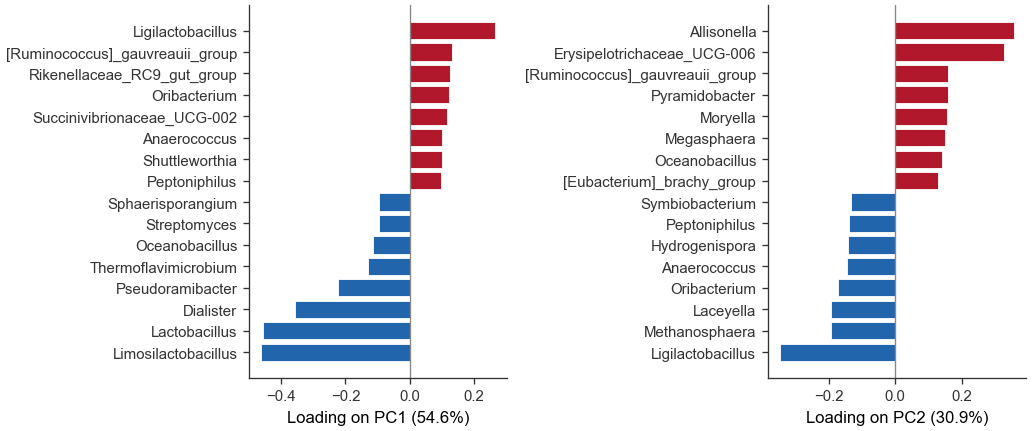

In [73]:
# We investigate the loadings to see which genera are driving the separation along PC1 and PC2. The loadings indicate how much each genus contributes to each principal component.

top_n = 8

# Loadings: one row per genus, one column per PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=clr_df.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

def top_loadings(pc_col, n=top_n):
    """Top n genera pulling positive + top n pulling negative on a given PC,
    combined and sorted for a clean diverging bar chart."""
    pos = loadings[pc_col].sort_values(ascending=False).head(n)
    neg = loadings[pc_col].sort_values(ascending=True).head(n)
    return pd.concat([pos, neg]).sort_values()

pc1_top = top_loadings("PC1")
pc2_top = top_loadings("PC2")

print("=== Top genera driving PC1 ===")
print(pc1_top.sort_values(ascending=False))
print(f"\n=== Top genera driving PC2 ===")
print(pc2_top.sort_values(ascending=False))


# Two-panel diverging bar chart: PC1 loadings | PC2 loadings

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE_PCA[0] * 2.2, FIGSIZE_PCA[1]))

for ax, (pc_col, pc_top, var) in zip(
    axes,
    [("PC1", pc1_top, var_exp[0]), ("PC2", pc2_top, var_exp[1])]
):
    colors = ['#B2182B' if v > 0 else '#2166AC' for v in pc_top.values]
    ax.barh(pc_top.index, pc_top.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color="#888888", lw=0.8)
    ax.set_xlabel(f"Loading on {pc_col} ({var:.1f}%)")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
save_fig(fig_dir, "pc1_pc2_top_loadings")
plt.show()

# Facet plot Ordenance and loadings

=== Top genera driving PC1 ===
Taxon_genus
Ligilactobacillus                  0.266038
[Ruminococcus]_gauvreauii_group    0.131875
Rikenellaceae_RC9_gut_group        0.124658
Oribacterium                       0.122835
Succinivibrionaceae_UCG-002        0.115668
Anaerococcus                       0.101117
Shuttleworthia                     0.099106
Peptoniphilus                      0.096843
Sphaerisporangium                 -0.096351
Streptomyces                      -0.096410
Oceanobacillus                    -0.114471
Thermoflavimicrobium              -0.129137
Pseudoramibacter                  -0.222194
Dialister                         -0.356247
Lactobacillus                     -0.456114
Limosilactobacillus               -0.463543
Name: PC1, dtype: float64

=== Top genera driving PC2 ===
Taxon_genus
Allisonella                        0.358520
Erysipelotrichaceae_UCG-006        0.326214
[Ruminococcus]_gauvreauii_group    0.159088
Pyramidobacter                     0.158289
Moryell

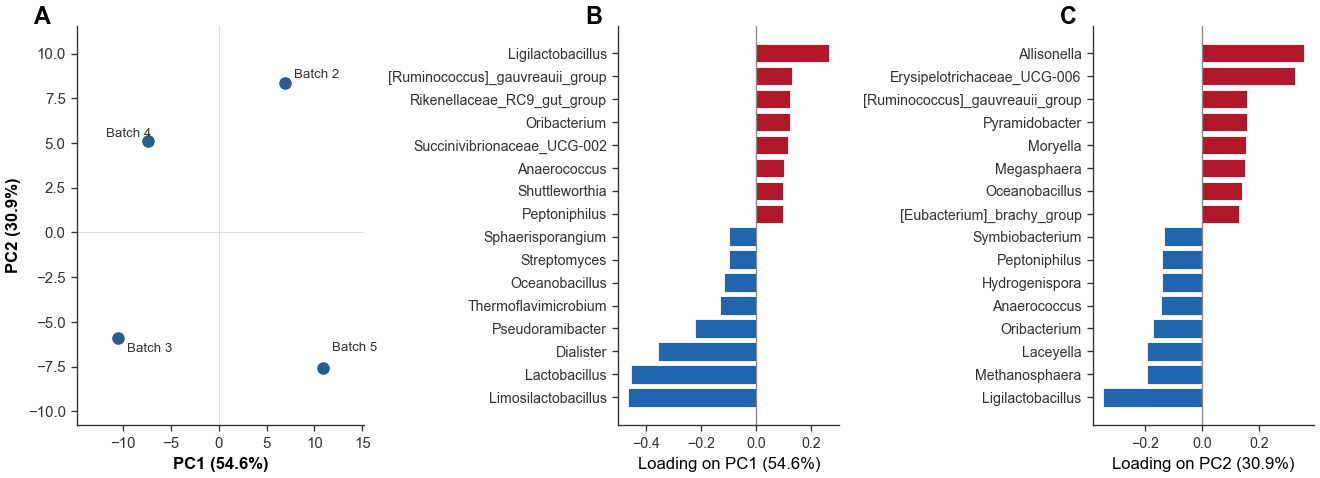

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- 1. Build genus x sample count table ----
genus_tab = (
    ec_tax0.groupby(["sample", "Taxon_genus"])["taxon_abun"]
    .sum().reset_index()
    .pivot_table(index="sample", columns="Taxon_genus", values="taxon_abun", fill_value=0)
)

# ---- 2. Bayesian multiplicative zero replacement ----
def multiplicative_replacement(mat, delta=None):
    mat = mat.astype(float).values
    props = mat / mat.sum(axis=1, keepdims=True)
    if delta is None:
        delta = np.min(props[props > 0]) * 0.65
    zero_mask = props == 0
    n_zeros = zero_mask.sum(axis=1, keepdims=True)
    props_repl = np.where(zero_mask, delta, props * (1 - n_zeros * delta))
    return props_repl

props = multiplicative_replacement(genus_tab)

# ---- 3. CLR transform ----
def clr(props):
    logp = np.log(props)
    return logp - logp.mean(axis=1, keepdims=True)

clr_mat = clr(props)
clr_df = pd.DataFrame(clr_mat, index=genus_tab.index, columns=genus_tab.columns)

# ---- 4. PCA ----
n_comp = min(3, clr_df.shape[0] - 1)
pca = PCA(n_components=n_comp)
scores = pca.fit_transform(clr_df.values)
var_exp = pca.explained_variance_ratio_ * 100

# ---- 5. Loadings ----
top_n = 8
loadings = pd.DataFrame(
    pca.components_.T,
    index=clr_df.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

def top_loadings(pc_col, n=top_n):
    pos = loadings[pc_col].sort_values(ascending=False).head(n)
    neg = loadings[pc_col].sort_values(ascending=True).head(n)
    return pd.concat([pos, neg]).sort_values()

pc1_top = top_loadings("PC1")
pc2_top = top_loadings("PC2")

print("=== Top genera driving PC1 ===")
print(pc1_top.sort_values(ascending=False))
print(f"\n=== Top genera driving PC2 ===")
print(pc2_top.sort_values(ascending=False))

# ---- 6. Combined 3-panel figure: A = PCA scatter, B/C = loadings ----
fig = plt.figure(figsize=(FIGSIZE_PCA[0] * 2.8, FIGSIZE_PCA[1] * 1.1))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1, 1])
ax_pca = fig.add_subplot(gs[0, 0])
ax_pc1 = fig.add_subplot(gs[0, 1])
ax_pc2 = fig.add_subplot(gs[0, 2])

# --- Panel A: PCA scatter ---
ax_pca.scatter(scores[:, 0], scores[:, 1], s=70, color='#2b5c8f',
               edgecolors='white', linewidths=0.8, zorder=3)
ax_pca.margins(0.2)

sample_labels = clr_df.index.tolist()
offsets = [(5, 3), (5, -8), (-25, 3), (5, 10), (-30, -8)]
for i, name in enumerate(sample_labels):
    dx, dy = offsets[i % len(offsets)]
    ax_pca.annotate(name, (scores[i, 0], scores[i, 1]), textcoords="offset points",
                     xytext=(dx, dy), fontsize=8, color='#333333')

if DATASET == "SBR":
    order = [s for s in ["Batch 2", "Batch 3", "Batch 4", "Batch 5"] if s in sample_labels]
    idx = [sample_labels.index(s) for s in order]

ax_pca.axhline(0, color="#e0e0e0", lw=0.6, zorder=1)
ax_pca.axvline(0, color="#e0e0e0", lw=0.6, zorder=1)
ax_pca.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=10, fontweight='bold')
ax_pca.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=10, fontweight='bold')
ax_pca.tick_params(labelsize=9)
ax_pca.text(-0.15, 1.05, "A", transform=ax_pca.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
ax_pca.spines['top'].set_visible(False)
ax_pca.spines['right'].set_visible(False)
ax_pca.spines['left'].set_color('#333333')
ax_pca.spines['bottom'].set_color('#333333')
ax_pca.spines['left'].set_linewidth(0.8)
ax_pca.spines['bottom'].set_linewidth(0.8)

# --- Panels B/C: PC1/PC2 loadings ---
for ax, (pc_col, pc_top, var, letter) in zip(
    [ax_pc1, ax_pc2],
    [("PC1", pc1_top, var_exp[0], "B"), ("PC2", pc2_top, var_exp[1], "C")]
):
    colors = ['#B2182B' if v > 0 else '#2166AC' for v in pc_top.values]
    ax.barh(pc_top.index, pc_top.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color="#888888", lw=0.8)
    ax.set_xlabel(f"Loading on {pc_col} ({var:.1f}%)", fontsize=10)
    ax.tick_params(labelsize=8.5)
    ax.text(-0.15, 1.05, letter, transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

plt.tight_layout()
save_fig(fig_dir, "clr_pca_and_loadings_combined")
plt.show()

# 6. Spearman correlation and yield analysis

This section is unique to the SBR dataset. Because all SBR batches were sequenced with the same primer set (341F/805R, V3-V4), Spearman correlation and leave-one-out sensitivity analysis are statistically valid here -- unlike the inoculum/proportions dataset, where a primer difference across sample groups made these analyses unreliable (see closing note in that notebook).

## Spearman correlation taxon to MCCA-potential contribution plot

In [75]:
# Load data for MCCA yields and productivity, clean it, and prepare for plotting

# 1. Load CSVs of "SBR data"
df_max_concentration = pd.read_csv(cfg["yields_dir"] / 'MCCA_Maximum_Concentration_g_L.csv', index_col=0)
df_productivity = pd.read_csv(cfg["yields_dir"] / 'MCCA_Productivity_mg_L_d.csv', index_col=0)
df_specific_productivity = pd.read_csv(cfg["yields_dir"] / 'MCCA_Specific_Productivity_mg_gTS_d.csv', index_col=0)

# 1. Alternatively, Load CSVs of "Inoculum and proportions data"
#df_max_concentration_raw = pd.read_csv(cfg["yields_dir"] / 'max_concentration_gL.csv')
# Set sample names as index BEFORE numeric conversion
#df_productivity_raw = pd.read_csv(cfg["yields_dir"] / 'productivity_volumetric_rate_mgLd.csv')
# Set sample names as index BEFORE numeric conversion

# sample names become index
#df_max_concentration = df_max_concentration_raw.set_index("sample")
#df_productivity = df_productivity_raw.set_index("sample")
#df_specific_productivity = df_specific_productivity_raw.set_index("sample")


# 2. Define your precise naming convention mapping
name_mapping = {
    "Propionic acid": "Propionic acid", #"propionate",
    "Isobutyric acid": "Isobutyric acid", #"isobutyrate",
    "Butyric acid": "Butyric acid", #"butyrate",
    "Valeric acid": "Valeric acid", #"valerate",
    "Isovaleric acid": "Isovaleric acid", #"isovalerate",
    "Hexanoic acid": "Hexanoic acid", #"caproate",
    "Heptanoic acid": "Heptanoic acid", #"heptanoate",
    "Octanoic acid": "Octanoic acid" #"caprylate"
}

# List of dataframes to process
dataframes = [df_max_concentration, df_productivity, df_specific_productivity]
#dataframes = [df_max_concentration_raw, df_productivity_raw]

# 3. Apply cleaning, numeric conversion, and name mapping to all
#for df in dataframes:
    # Rename rows using the required naming convention
#    df.index = df.index.map(name_mapping)
    
    # Process each column to strip SD and replace missing data with 0
#    for col in df.columns:
#        df[col] = df[col].astype(str).str.split('±').str[0].str.strip()
#        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
#        df[col] = pd.to_numeric(df[col].replace('-', 0))

valid_targets = set(name_mapping.values())

def safe_rename(idx_val):
    if idx_val in valid_targets:
        return idx_val              # already in the target convention -- leave as-is
    return name_mapping.get(idx_val, idx_val)  # else remap if possible, otherwise leave unchanged (never NaN)

for df in dataframes:
    df.index = df.index.map(safe_rename)
    for col in df.columns:
        df[col] = df[col].astype(str).str.split('±').str[0].str.strip()
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        
#for df in [df_max_concentration, df_productivity, df_specific_productivity]:

#    for col in df.columns:
#        df[col] = (
#            df[col]
#            .astype(str)
#            .str.split("±").str[0]
#            .str.strip()
#            .replace("-", 0)
#        )

#        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Now all three dataframes are pure numeric float matrices with your updated index nomenclature!

## Heatmap: Max concentration vs Key functional taxa  

Selected candidate taxa (by summed inferred functional abundance): ['[Eubacterium]_nodatum_group', 'Lachnospiraceae_NK3A20_group', 'Limosilactobacillus', 'Unclassified', 'Syntrophococcus', 'Olsenella', 'Lactobacillus', 'Dialister', 'Ligilactobacillus', 'Prevotella_7']


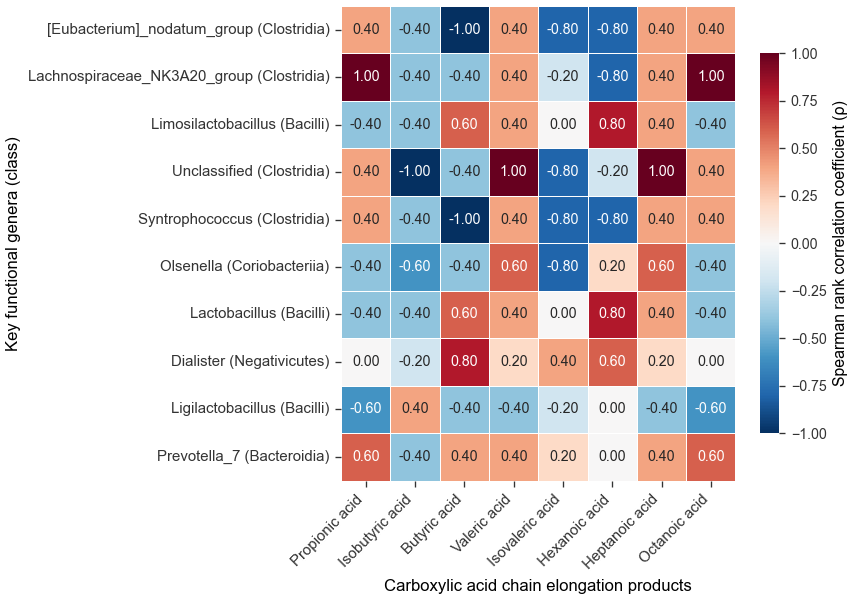

In [76]:
# 1. Prepare and transpose the clean numeric yield matrix (Samples = Rows)
yields_matrix = df_max_concentration.T  
#yields_matrix = df_max_concentration.copy()

carbon_chain_order = [
    'Propionic acid', 'Isobutyric acid', 'Butyric acid', 'Valeric acid',
    'Isovaleric acid', 'Hexanoic acid', 'Heptanoic acid', 'Octanoic acid'
]
available_mccas = [mcca for mcca in carbon_chain_order if mcca in yields_matrix.columns]

# 2. Select candidate taxa using summed PICRUSt2 predicted functional
# abundance for the carboxylic-acid pathway set (taxon_rel_function_abun;
# NO completeness weighting -- carboxylic_acid_ec's categories share
# extensive, pervasive EC overlap, e.g. caproate/caprylate are 100%
# identical and valerate/heptanoate 92-100%, so a per-category
# completeness fraction would not measure independent pathway presence).
#
# Rebuilt independently from ec_tax0 (not the shared, mutable df2) so this
# cell doesn't depend on what any other cell left df2 as.

_exact_map, _wildcard_map = build_ec_maps(carboxylic_acid_ec)

def _map_ec_to_products_local(ec):
    products = set()
    if ec in _exact_map:
        products.update(_exact_map[ec])
    for prefix, product in _wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

_ec_tax_cand = ec_tax0.copy()
_ec_tax_cand["mcca_bioproduct"] = _ec_tax_cand["function"].apply(_map_ec_to_products_local)
_df_cand_bp = _ec_tax_cand.explode("mcca_bioproduct").dropna(subset=["mcca_bioproduct"]).copy()
_df_cand_bp = _df_cand_bp[_df_cand_bp["taxon_rel_function_abun"] > 1e-4].copy()

candidate_taxa = (
    _df_cand_bp.groupby("Taxon_genus")["taxon_rel_function_abun"].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
candidate_taxa = [t for t in candidate_taxa if t in clr_df.columns]
print("Selected candidate taxa (by summed inferred functional abundance):", candidate_taxa)

# 3. Align sample IDs
common = clr_df.index.intersection(yields_matrix.index)
assert len(common) >= 3, "Sample IDs do not match between clr_df and yields matrix!"
X = clr_df.loc[common, candidate_taxa]

# 4. Spearman coefficient matrix
# FIXED: properly drop NaNs per pair (e.g. Wine's missing caprylate) instead
# of silently converting "could not be computed" into rho=0.0, which made
# missing data visually indistinguishable from a genuine null correlation.
MIN_N_FOR_CORR = 4  # below this, Spearman is too degenerate to report

def spearman_dropna(x, y):
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < MIN_N_FOR_CORR:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used

corr_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)
n_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)

for mcca_product in available_mccas:
    y_mcca = yields_matrix.loc[common, mcca_product]
    for t in candidate_taxa:
        rho, n_used = spearman_dropna(X[t], y_mcca)
        corr_matrix.loc[t, mcca_product] = rho
        n_matrix.loc[t, mcca_product] = n_used

corr_matrix = corr_matrix.astype(float)  # NaN where insufficient data -- no longer masked as 0.0

# NEW: "Genus (Class)" row labels (reuse genus_to_class + genus_display_label)
def genus_display_label(g):
    return "Other" if g == "Other" else f"{g} ({genus_to_class.get(g, 'Unclassified')})"

row_labels = [genus_display_label(t) for t in corr_matrix.index]

# 5. Build heatmap
fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)

# Cells with insufficient data (NaN) are masked -- shown as blank/gray rather
# than a misleading "0.00", so missing data is visually distinct from a
# genuinely computed null correlation.
mask = corr_matrix.isna()

annot_labels = corr_matrix.copy().astype(object)
for t in corr_matrix.index:
    for mcca in corr_matrix.columns:
        r = corr_matrix.loc[t, mcca]
        annot_labels.loc[t, mcca] = "n/a" if pd.isna(r) else f"{r:.2f}"

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=annot_labels.values,
    fmt="",
    cmap=CMAP_DIVERGING,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Spearman rank correlation coefficient (ρ)', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=row_labels,
    ax=ax,
)
ax.set_facecolor("#e8e8e8")  # masked/NaN cells show as light gray, not blank white

cbar = ax.collections[0].colorbar
cbar.set_label('Spearman rank correlation coefficient (ρ)', size=9.5)
cbar.ax.tick_params(labelsize=8.5)

ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_max_concentration_weighted_heatmap")
plt.show()

# Report which cells were insufficient (previously silently shown as 0.00)
insufficient = n_matrix[corr_matrix.isna()].stack()
if len(insufficient) > 0:
    print(f"\n{len(insufficient)} genus-product pairs had insufficient data (n < {MIN_N_FOR_CORR}) and are shown as gray/n.a.:")
    print(insufficient.rename("n_valid").to_string())

In [77]:
corr_matrix

,Propionic acid,Isobutyric acid,Butyric acid,Valeric acid,Isovaleric acid,Hexanoic acid,Heptanoic acid,Octanoic acid
[Eubacterium]_nodatum_group,0.4,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Lachnospiraceae_NK3A20_group,1.0,-0.4,-0.4,0.4,-0.2,-0.8,0.4,1.0
Limosilactobacillus,-0.4,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Unclassified,0.4,-1.0,-0.4,1.0,-0.8,-0.2,1.0,0.4
Syntrophococcus,0.4,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Olsenella,-0.4,-0.6,-0.4,0.6,-0.8,0.2,0.6,-0.4
Lactobacillus,-0.4,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Dialister,0.0,-0.2,0.8,0.2,0.4,0.6,0.2,0.0
Ligilactobacillus,-0.6,0.4,-0.4,-0.4,-0.2,0.0,-0.4,-0.6
Prevotella_7,0.6,-0.4,0.4,0.4,0.2,0.0,0.4,0.6


### Leave-one-out (LOO) Max Concentration

Products with fewer than 5 valid samples (LOO drops these to n=3, near the
floor of what Spearman can meaningfully report -- treat as a qualitative stability
indicator only, not a quantitative sensitivity measure):
        product  n_valid_samples
 Propionic acid                4
Isobutyric acid                4
   Butyric acid                4
   Valeric acid                4
Isovaleric acid                4
  Hexanoic acid                4
 Heptanoic acid                4
  Octanoic acid                4

53 of 80 genus-product pairs had a SIGN FLIP under leave-one-out:
                       genus         product  baseline_rho  loo_rho_min  loo_rho_max
           Ligilactobacillus    Butyric acid          -0.4         -1.0          0.5
                Prevotella_7    Butyric acid           0.4         -0.5          1.0
                   Olsenella    Butyric acid          -0.4         -1.0          0.5
                Unclassified    Butyric acid          -0.4         -1.0          

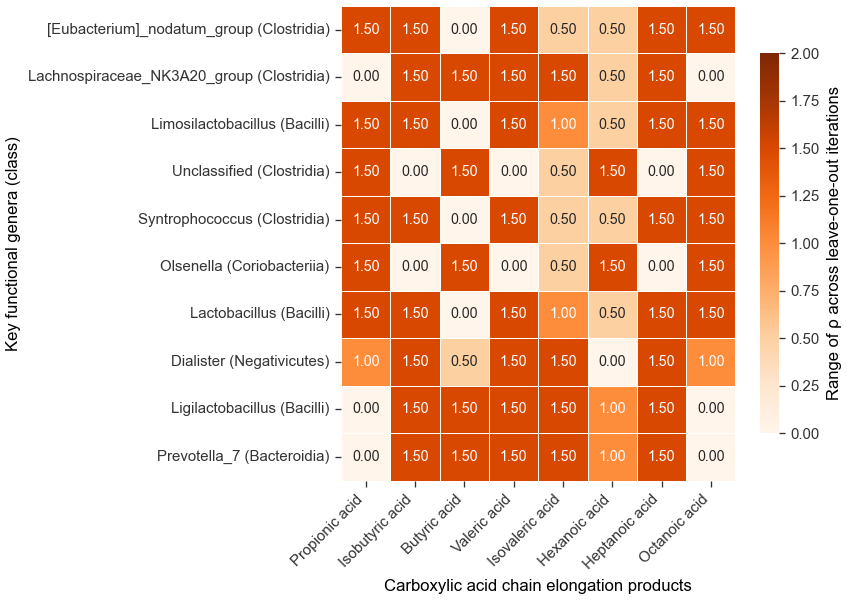

In [78]:
# =====================================================
# Leave-one-out (LOO) sensitivity analysis for the Spearman heatmap above.
#
# At this sample size, any single influential sample can dominate a
# correlation. This recomputes each genus-product rho with one sample
# removed at a time, and reports how much rho moves -- including whether
# its SIGN flips, which is the strongest signal that a reported
# correlation is an artifact of one data point rather than a real trend.
#
# NOTE on thresholds: the baseline correlation requires the full valid
# sample set (MIN_N_FOR_CORR). Each LOO iteration inherently drops to one
# fewer sample by design, so it uses a separate, lower threshold
# (MIN_N_FOR_LOO) -- otherwise, at small total sample sizes (e.g. n=4),
# EVERY LOO iteration falls below the baseline threshold and the entire
# analysis silently returns NaN everywhere (axes/colorbar render, but no
# cells -- exactly the bug this fixes).
# =====================================================

MIN_N_FOR_CORR = 4   # baseline correlation: require the full valid sample set
MIN_N_FOR_LOO = 3     # LOO iterations: inherently n-1 samples relative to baseline

def spearman_dropna(x, y, min_n=MIN_N_FOR_CORR):
    """Spearman correlation after properly dropping any sample with a NaN
    in either x or y. Returns (rho, n_used); rho is np.nan if n_used < min_n
    or if either variable has zero variance among the valid points."""
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < min_n:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used


loo_records = []

for mcca_product in available_mccas:
    y_full = yields_matrix.loc[common, mcca_product]
    valid_samples = y_full.dropna().index.tolist()  # samples actually measured for this product
    n_valid = len(valid_samples)

    for t in candidate_taxa:
        x_full = X.loc[valid_samples, t]
        y_valid = y_full.loc[valid_samples]

        # Baseline: full valid sample set, strict threshold
        baseline_rho, baseline_n = spearman_dropna(x_full, y_valid, min_n=MIN_N_FOR_CORR)

        # LOO: each iteration drops one sample -- relaxed threshold
        loo_rhos = []
        for held_out in valid_samples:
            keep = [s for s in valid_samples if s != held_out]
            rho_i, n_i = spearman_dropna(x_full.loc[keep], y_valid.loc[keep], min_n=MIN_N_FOR_LOO)
            loo_rhos.append(rho_i)

        loo_rhos_clean = [r for r in loo_rhos if not np.isnan(r)]

        if loo_rhos_clean:
            rho_min, rho_max = min(loo_rhos_clean), max(loo_rhos_clean)
            rho_range = rho_max - rho_min
            signs = set(np.sign(r) for r in loo_rhos_clean if r != 0)
            sign_flip = len(signs) > 1
        else:
            rho_min = rho_max = rho_range = np.nan
            sign_flip = None

        loo_records.append({
            "genus": t, "product": mcca_product, "n_valid_samples": n_valid,
            "baseline_rho": baseline_rho, "loo_rho_min": rho_min,
            "loo_rho_max": rho_max, "loo_rho_range": rho_range,
            "sign_flip_under_LOO": sign_flip,
        })

loo_df = pd.DataFrame(loo_records)

low_n = loo_df[loo_df["n_valid_samples"] < 5]
if not low_n.empty:
    print(f"Products with fewer than 5 valid samples (LOO drops these to n={MIN_N_FOR_LOO}, near the")
    print("floor of what Spearman can meaningfully report -- treat as a qualitative stability")
    print("indicator only, not a quantitative sensitivity measure):")
    print(low_n[["product", "n_valid_samples"]].drop_duplicates().to_string(index=False))
    print()

flipped = loo_df[loo_df["sign_flip_under_LOO"] == True]
print(f"{len(flipped)} of {len(loo_df)} genus-product pairs had a SIGN FLIP under leave-one-out:")
print(flipped[["genus", "product", "baseline_rho", "loo_rho_min", "loo_rho_max"]]
      .sort_values("product").to_string(index=False))
print()

# ---- Heatmap: range of rho across LOO iterations ----
range_pivot = loo_df.pivot_table(index="genus", columns="product", values="loo_rho_range")
range_pivot = range_pivot.reindex(index=candidate_taxa, columns=available_mccas)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)
sns.heatmap(
    range_pivot, annot=True, fmt=".2f", cmap="Oranges", vmin=0, vmax=2,
    linewidths=0.5, linecolor="white",
    cbar_kws={'label': 'Range of ρ across leave-one-out iterations', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=[genus_display_label(t) for t in range_pivot.index],
    ax=ax,
)
ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_loo_sensitivity_range_max_concentration_heatmap")
plt.show()

# Facet plot: heatmap + LOO (Max concentration)

Selected candidate taxa (by summed inferred functional abundance): ['[Eubacterium]_nodatum_group', 'Lachnospiraceae_NK3A20_group', 'Limosilactobacillus', 'Unclassified', 'Syntrophococcus', 'Olsenella', 'Lactobacillus', 'Dialister', 'Ligilactobacillus', 'Prevotella_7']
Products with fewer than 5 valid samples (LOO drops these to n=3, near the
floor of what Spearman can meaningfully report -- treat as a qualitative stability
indicator only, not a quantitative sensitivity measure):
        product  n_valid_samples
 Propionic acid                4
Isobutyric acid                4
   Butyric acid                4
   Valeric acid                4
Isovaleric acid                4
  Hexanoic acid                4
 Heptanoic acid                4
  Octanoic acid                4

53 of 80 genus-product pairs had a SIGN FLIP under leave-one-out:
                       genus         product  baseline_rho  loo_rho_min  loo_rho_max
           Ligilactobacillus    Butyric acid          -0.4         

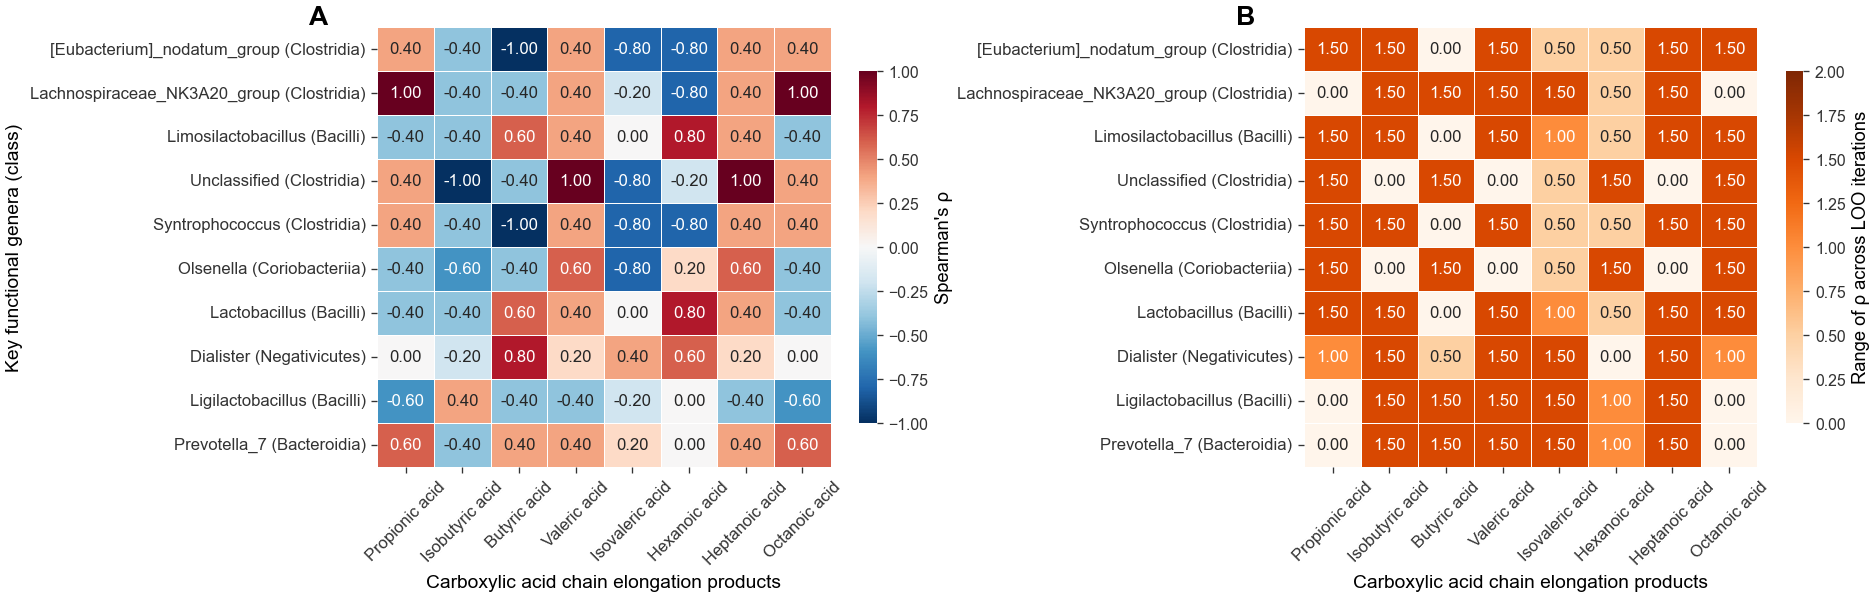

In [79]:
# =====================================================
# Combined figure: Spearman correlation heatmap (Panel A) +
# leave-one-out sensitivity range (Panel B), maximum concentration.
# =====================================================

# ---- 1. Prepare the clean numeric yield matrix (Samples = Rows) ----
yields_matrix = df_max_concentration.T

carbon_chain_order = [
    'Propionic acid', 'Isobutyric acid', 'Butyric acid', 'Valeric acid',
    'Isovaleric acid', 'Hexanoic acid', 'Heptanoic acid', 'Octanoic acid'
]
available_mccas = [mcca for mcca in carbon_chain_order if mcca in yields_matrix.columns]

# ---- 2. Select candidate taxa using summed PICRUSt2 predicted functional
# abundance for the carboxylic-acid pathway set (taxon_rel_function_abun;
# NO completeness weighting -- carboxylic_acid_ec's categories share
# extensive, pervasive EC overlap, e.g. caproate/caprylate are 100%
# identical and valerate/heptanoate 92-100%, so a per-category
# completeness fraction would not measure independent pathway presence).
#
# Rebuilt independently from ec_tax0 (not the shared, mutable df2) so this
# cell doesn't depend on what any other cell left df2 as.

_exact_map, _wildcard_map = build_ec_maps(carboxylic_acid_ec)

def _map_ec_to_products_local(ec):
    products = set()
    if ec in _exact_map:
        products.update(_exact_map[ec])
    for prefix, product in _wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

_ec_tax_cand = ec_tax0.copy()
_ec_tax_cand["mcca_bioproduct"] = _ec_tax_cand["function"].apply(_map_ec_to_products_local)
_df_cand_bp = _ec_tax_cand.explode("mcca_bioproduct").dropna(subset=["mcca_bioproduct"]).copy()
_df_cand_bp = _df_cand_bp[_df_cand_bp["taxon_rel_function_abun"] > 1e-4].copy()

candidate_taxa = (
    _df_cand_bp.groupby("Taxon_genus")["taxon_rel_function_abun"].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
candidate_taxa = [t for t in candidate_taxa if t in clr_df.columns]
print("Selected candidate taxa (by summed inferred functional abundance):", candidate_taxa)

# ---- 3. Align sample IDs ----
common = clr_df.index.intersection(yields_matrix.index)
assert len(common) >= 3, "Sample IDs do not match between clr_df and yields matrix!"
X = clr_df.loc[common, candidate_taxa]

# ---- 4. Spearman coefficient matrix ----
MIN_N_FOR_CORR = 4  # below this, Spearman is too degenerate to report

def spearman_dropna(x, y, min_n=MIN_N_FOR_CORR):
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < min_n:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used

corr_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)
n_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)

for mcca_product in available_mccas:
    y_mcca = yields_matrix.loc[common, mcca_product]
    for t in candidate_taxa:
        rho, n_used = spearman_dropna(X[t], y_mcca)
        corr_matrix.loc[t, mcca_product] = rho
        n_matrix.loc[t, mcca_product] = n_used

corr_matrix = corr_matrix.astype(float)

def genus_display_label(g):
    return "Other" if g == "Other" else f"{g} ({genus_to_class.get(g, 'Unclassified')})"

row_labels = [genus_display_label(t) for t in corr_matrix.index]

# ---- 5. Leave-one-out sensitivity analysis ----
MIN_N_FOR_LOO = 3  # LOO iterations inherently drop to n-1 relative to baseline

loo_records = []

for mcca_product in available_mccas:
    y_full = yields_matrix.loc[common, mcca_product]
    valid_samples = y_full.dropna().index.tolist()
    n_valid = len(valid_samples)

    for t in candidate_taxa:
        x_full = X.loc[valid_samples, t]
        y_valid = y_full.loc[valid_samples]

        baseline_rho, baseline_n = spearman_dropna(x_full, y_valid, min_n=MIN_N_FOR_CORR)

        loo_rhos = []
        for held_out in valid_samples:
            keep = [s for s in valid_samples if s != held_out]
            rho_i, n_i = spearman_dropna(x_full.loc[keep], y_valid.loc[keep], min_n=MIN_N_FOR_LOO)
            loo_rhos.append(rho_i)

        loo_rhos_clean = [r for r in loo_rhos if not np.isnan(r)]

        if loo_rhos_clean:
            rho_min, rho_max = min(loo_rhos_clean), max(loo_rhos_clean)
            rho_range = rho_max - rho_min
            signs = set(np.sign(r) for r in loo_rhos_clean if r != 0)
            sign_flip = len(signs) > 1
        else:
            rho_min = rho_max = rho_range = np.nan
            sign_flip = None

        loo_records.append({
            "genus": t, "product": mcca_product, "n_valid_samples": n_valid,
            "baseline_rho": baseline_rho, "loo_rho_min": rho_min,
            "loo_rho_max": rho_max, "loo_rho_range": rho_range,
            "sign_flip_under_LOO": sign_flip,
        })

loo_df = pd.DataFrame(loo_records)

low_n = loo_df[loo_df["n_valid_samples"] < 5]
if not low_n.empty:
    print(f"Products with fewer than 5 valid samples (LOO drops these to n={MIN_N_FOR_LOO}, near the")
    print("floor of what Spearman can meaningfully report -- treat as a qualitative stability")
    print("indicator only, not a quantitative sensitivity measure):")
    print(low_n[["product", "n_valid_samples"]].drop_duplicates().to_string(index=False))
    print()

flipped = loo_df[loo_df["sign_flip_under_LOO"] == True]
print(f"{len(flipped)} of {len(loo_df)} genus-product pairs had a SIGN FLIP under leave-one-out:")
print(flipped[["genus", "product", "baseline_rho", "loo_rho_min", "loo_rho_max"]]
      .sort_values("product").to_string(index=False))
print()

range_pivot = loo_df.pivot_table(index="genus", columns="product", values="loo_rho_range")
range_pivot = range_pivot.reindex(index=candidate_taxa, columns=available_mccas)

# ---- 6. Combined figure: Panel A = correlation heatmap, Panel B = LOO range ----
fig, (ax_corr, ax_loo) = plt.subplots(1, 2, figsize=(FIGSIZE_HEATMAP[0] * 2.2, FIGSIZE_HEATMAP[1]))

# --- Panel A: correlation heatmap ---
mask = corr_matrix.isna()
annot_labels = corr_matrix.copy().astype(object)
for t in corr_matrix.index:
    for mcca in corr_matrix.columns:
        r = corr_matrix.loc[t, mcca]
        annot_labels.loc[t, mcca] = "n/a" if pd.isna(r) else f"{r:.2f}"

sns.heatmap(
    corr_matrix, mask=mask, annot=annot_labels.values, fmt="",
    cmap=CMAP_DIVERGING, vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
    cbar_kws={'label': "Spearman's ρ", 'shrink': 0.8},
    annot_kws={"size": 10}, yticklabels=row_labels, ax=ax_corr,
)
ax_corr.set_facecolor("#e8e8e8")
ax_corr.set_ylabel("Key functional genera (class)", fontsize=11.5)
ax_corr.set_xlabel("Carboxylic acid chain elongation products", fontsize=11.5)
ax_corr.tick_params(axis='x', labelrotation=45, labelsize=10)
ax_corr.tick_params(axis='y', labelsize=10)
ax_corr.text(-0.15, 1.05, "A", transform=ax_corr.transAxes, fontsize=16,
             fontweight="bold", va="top", ha="left")

cbar_a = ax_corr.collections[0].colorbar
cbar_a.set_label("Spearman's ρ", size=11)
cbar_a.ax.tick_params(labelsize=9.5)

# --- Panel B: LOO sensitivity range ---
sns.heatmap(
    range_pivot, annot=True, fmt=".2f", cmap="Oranges", vmin=0, vmax=2,
    linewidths=0.5, linecolor="white",
    cbar_kws={'label': 'Range of ρ across LOO iterations', 'shrink': 0.8},
    annot_kws={"size": 10},
    yticklabels=[genus_display_label(t) for t in range_pivot.index],
    ax=ax_loo,
)
ax_loo.set_ylabel("")
ax_loo.set_xlabel("Carboxylic acid chain elongation products", fontsize=11.5)
ax_loo.tick_params(axis='x', labelrotation=45, labelsize=10)
ax_loo.tick_params(axis='y', labelsize=10)
ax_loo.text(-0.15, 1.05, "B", transform=ax_loo.transAxes, fontsize=16,
            fontweight="bold", va="top", ha="left")

cbar_b = ax_loo.collections[0].colorbar
cbar_b.set_label('Range of ρ across LOO iterations', size=11)
cbar_b.ax.tick_params(labelsize=9.5)

plt.tight_layout()
save_fig(fig_dir, "correlation_and_LOO_combined")
plt.show()

# ---- Report which cells were insufficient ----
insufficient = n_matrix[corr_matrix.isna()].stack()
if len(insufficient) > 0:
    print(f"\n{len(insufficient)} genus-product pairs had insufficient data (n < {MIN_N_FOR_CORR}) and are shown as gray/n.a.:")
    print(insufficient.rename("n_valid").to_string())

## Heatmap: Productivity vs Key functional taxa  

Selected candidate taxa (by summed inferred functional abundance): ['[Eubacterium]_nodatum_group', 'Lachnospiraceae_NK3A20_group', 'Limosilactobacillus', 'Unclassified', 'Syntrophococcus', 'Olsenella', 'Lactobacillus', 'Dialister', 'Ligilactobacillus', 'Prevotella_7']


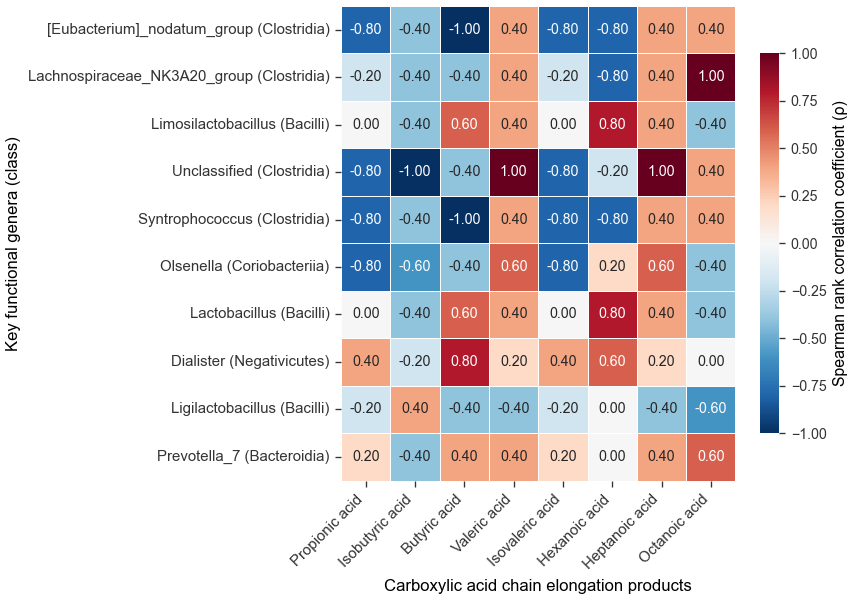

In [80]:
# 1. Prepare and transpose the clean numeric yield matrix (Samples = Rows)
yields_matrix = df_productivity.T  
#yields_matrix = df_productivity.copy()

carbon_chain_order = [
    'Propionic acid', 'Isobutyric acid', 'Butyric acid', 'Valeric acid',
    'Isovaleric acid', 'Hexanoic acid', 'Heptanoic acid', 'Octanoic acid'
]
available_mccas = [mcca for mcca in carbon_chain_order if mcca in yields_matrix.columns]

# 2. Select candidate taxa using summed PICRUSt2 predicted functional
# abundance for the carboxylic-acid pathway set (taxon_rel_function_abun;
# NO completeness weighting -- carboxylic_acid_ec's categories share
# extensive, pervasive EC overlap, e.g. caproate/caprylate are 100%
# identical and valerate/heptanoate 92-100%, so a per-category
# completeness fraction would not measure independent pathway presence).
#
# Rebuilt independently from ec_tax0 (not the shared, mutable df2) so this
# cell doesn't depend on what any other cell left df2 as.

_exact_map, _wildcard_map = build_ec_maps(carboxylic_acid_ec)

def _map_ec_to_products_local(ec):
    products = set()
    if ec in _exact_map:
        products.update(_exact_map[ec])
    for prefix, product in _wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

_ec_tax_cand = ec_tax0.copy()
_ec_tax_cand["mcca_bioproduct"] = _ec_tax_cand["function"].apply(_map_ec_to_products_local)
_df_cand_bp = _ec_tax_cand.explode("mcca_bioproduct").dropna(subset=["mcca_bioproduct"]).copy()
_df_cand_bp = _df_cand_bp[_df_cand_bp["taxon_rel_function_abun"] > 1e-4].copy()

candidate_taxa = (
    _df_cand_bp.groupby("Taxon_genus")["taxon_rel_function_abun"].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
candidate_taxa = [t for t in candidate_taxa if t in clr_df.columns]
print("Selected candidate taxa (by summed inferred functional abundance):", candidate_taxa)

# 3. Align sample IDs
common = clr_df.index.intersection(yields_matrix.index)
assert len(common) >= 3, "Sample IDs do not match between clr_df and yields matrix!"
X = clr_df.loc[common, candidate_taxa]

# 4. Spearman coefficient matrix
# FIXED: properly drop NaNs per pair (e.g. Wine's missing caprylate) instead
# of silently converting "could not be computed" into rho=0.0, which made
# missing data visually indistinguishable from a genuine null correlation.
MIN_N_FOR_CORR = 4  # below this, Spearman is too degenerate to report

def spearman_dropna(x, y):
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < MIN_N_FOR_CORR:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used

corr_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)
n_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas, dtype=float)

for mcca_product in available_mccas:
    y_mcca = yields_matrix.loc[common, mcca_product]
    for t in candidate_taxa:
        rho, n_used = spearman_dropna(X[t], y_mcca)
        corr_matrix.loc[t, mcca_product] = rho
        n_matrix.loc[t, mcca_product] = n_used

corr_matrix = corr_matrix.astype(float)  # NaN where insufficient data -- no longer masked as 0.0

# NEW: "Genus (Class)" row labels (reuse genus_to_class + genus_display_label)
def genus_display_label(g):
    return "Other" if g == "Other" else f"{g} ({genus_to_class.get(g, 'Unclassified')})"

row_labels = [genus_display_label(t) for t in corr_matrix.index]

# 5. Build heatmap
fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)

# Cells with insufficient data (NaN) are masked -- shown as blank/gray rather
# than a misleading "0.00", so missing data is visually distinct from a
# genuinely computed null correlation.
mask = corr_matrix.isna()

annot_labels = corr_matrix.copy().astype(object)
for t in corr_matrix.index:
    for mcca in corr_matrix.columns:
        r = corr_matrix.loc[t, mcca]
        annot_labels.loc[t, mcca] = "n/a" if pd.isna(r) else f"{r:.2f}"

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=annot_labels.values,
    fmt="",
    cmap=CMAP_DIVERGING,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Spearman rank correlation coefficient (ρ)', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=row_labels,
    ax=ax,
)
ax.set_facecolor("#e8e8e8")  # masked/NaN cells show as light gray, not blank white

cbar = ax.collections[0].colorbar
cbar.set_label('Spearman rank correlation coefficient (ρ)', size=9.5)
cbar.ax.tick_params(labelsize=8.5)

ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_max_concentration_weighted_heatmap")
plt.show()

# Report which cells were insufficient (previously silently shown as 0.00)
insufficient = n_matrix[corr_matrix.isna()].stack()
if len(insufficient) > 0:
    print(f"\n{len(insufficient)} genus-product pairs had insufficient data (n < {MIN_N_FOR_CORR}) and are shown as gray/n.a.:")
    print(insufficient.rename("n_valid").to_string())

In [81]:
corr_matrix

,Propionic acid,Isobutyric acid,Butyric acid,Valeric acid,Isovaleric acid,Hexanoic acid,Heptanoic acid,Octanoic acid
[Eubacterium]_nodatum_group,-0.8,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Lachnospiraceae_NK3A20_group,-0.2,-0.4,-0.4,0.4,-0.2,-0.8,0.4,1.0
Limosilactobacillus,0.0,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Unclassified,-0.8,-1.0,-0.4,1.0,-0.8,-0.2,1.0,0.4
Syntrophococcus,-0.8,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Olsenella,-0.8,-0.6,-0.4,0.6,-0.8,0.2,0.6,-0.4
Lactobacillus,0.0,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Dialister,0.4,-0.2,0.8,0.2,0.4,0.6,0.2,0.0
Ligilactobacillus,-0.2,0.4,-0.4,-0.4,-0.2,0.0,-0.4,-0.6
Prevotella_7,0.2,-0.4,0.4,0.4,0.2,0.0,0.4,0.6


### Leave-one-out (LOO) Productivity

Products with fewer than 5 valid samples (LOO drops these to n=3, near the
floor of what Spearman can meaningfully report -- treat as a qualitative stability
indicator only, not a quantitative sensitivity measure):
        product  n_valid_samples
 Propionic acid                4
Isobutyric acid                4
   Butyric acid                4
   Valeric acid                4
Isovaleric acid                4
  Hexanoic acid                4
 Heptanoic acid                4
  Octanoic acid                4

52 of 80 genus-product pairs had a SIGN FLIP under leave-one-out:
                       genus         product  baseline_rho  loo_rho_min  loo_rho_max
                Prevotella_7    Butyric acid           0.4         -0.5          1.0
           Ligilactobacillus    Butyric acid          -0.4         -1.0          0.5
                   Olsenella    Butyric acid          -0.4         -1.0          0.5
                Unclassified    Butyric acid          -0.4         -1.0          

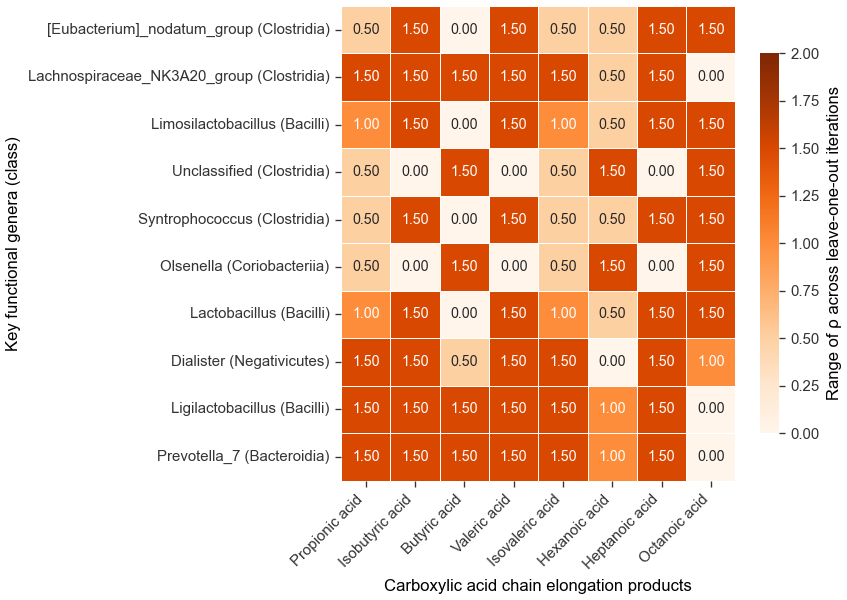

In [82]:
# =====================================================
# Leave-one-out (LOO) sensitivity analysis for the Spearman heatmap above.
#
# At this sample size, any single influential sample can dominate a
# correlation. This recomputes each genus-product rho with one sample
# removed at a time, and reports how much rho moves -- including whether
# its SIGN flips, which is the strongest signal that a reported
# correlation is an artifact of one data point rather than a real trend.
#
# NOTE on thresholds: the baseline correlation requires the full valid
# sample set (MIN_N_FOR_CORR). Each LOO iteration inherently drops to one
# fewer sample by design, so it uses a separate, lower threshold
# (MIN_N_FOR_LOO) -- otherwise, at small total sample sizes (e.g. n=4),
# EVERY LOO iteration falls below the baseline threshold and the entire
# analysis silently returns NaN everywhere (axes/colorbar render, but no
# cells -- exactly the bug this fixes).
# =====================================================

MIN_N_FOR_CORR = 4   # baseline correlation: require the full valid sample set
MIN_N_FOR_LOO = 3     # LOO iterations: inherently n-1 samples relative to baseline

def spearman_dropna(x, y, min_n=MIN_N_FOR_CORR):
    """Spearman correlation after properly dropping any sample with a NaN
    in either x or y. Returns (rho, n_used); rho is np.nan if n_used < min_n
    or if either variable has zero variance among the valid points."""
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < min_n:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used


loo_records = []

for mcca_product in available_mccas:
    y_full = yields_matrix.loc[common, mcca_product]
    valid_samples = y_full.dropna().index.tolist()  # samples actually measured for this product
    n_valid = len(valid_samples)

    for t in candidate_taxa:
        x_full = X.loc[valid_samples, t]
        y_valid = y_full.loc[valid_samples]

        # Baseline: full valid sample set, strict threshold
        baseline_rho, baseline_n = spearman_dropna(x_full, y_valid, min_n=MIN_N_FOR_CORR)

        # LOO: each iteration drops one sample -- relaxed threshold
        loo_rhos = []
        for held_out in valid_samples:
            keep = [s for s in valid_samples if s != held_out]
            rho_i, n_i = spearman_dropna(x_full.loc[keep], y_valid.loc[keep], min_n=MIN_N_FOR_LOO)
            loo_rhos.append(rho_i)

        loo_rhos_clean = [r for r in loo_rhos if not np.isnan(r)]

        if loo_rhos_clean:
            rho_min, rho_max = min(loo_rhos_clean), max(loo_rhos_clean)
            rho_range = rho_max - rho_min
            signs = set(np.sign(r) for r in loo_rhos_clean if r != 0)
            sign_flip = len(signs) > 1
        else:
            rho_min = rho_max = rho_range = np.nan
            sign_flip = None

        loo_records.append({
            "genus": t, "product": mcca_product, "n_valid_samples": n_valid,
            "baseline_rho": baseline_rho, "loo_rho_min": rho_min,
            "loo_rho_max": rho_max, "loo_rho_range": rho_range,
            "sign_flip_under_LOO": sign_flip,
        })

loo_df = pd.DataFrame(loo_records)

low_n = loo_df[loo_df["n_valid_samples"] < 5]
if not low_n.empty:
    print(f"Products with fewer than 5 valid samples (LOO drops these to n={MIN_N_FOR_LOO}, near the")
    print("floor of what Spearman can meaningfully report -- treat as a qualitative stability")
    print("indicator only, not a quantitative sensitivity measure):")
    print(low_n[["product", "n_valid_samples"]].drop_duplicates().to_string(index=False))
    print()

flipped = loo_df[loo_df["sign_flip_under_LOO"] == True]
print(f"{len(flipped)} of {len(loo_df)} genus-product pairs had a SIGN FLIP under leave-one-out:")
print(flipped[["genus", "product", "baseline_rho", "loo_rho_min", "loo_rho_max"]]
      .sort_values("product").to_string(index=False))
print()

# ---- Heatmap: range of rho across LOO iterations ----
range_pivot = loo_df.pivot_table(index="genus", columns="product", values="loo_rho_range")
range_pivot = range_pivot.reindex(index=candidate_taxa, columns=available_mccas)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)
sns.heatmap(
    range_pivot, annot=True, fmt=".2f", cmap="Oranges", vmin=0, vmax=2,
    linewidths=0.5, linecolor="white",
    cbar_kws={'label': 'Range of ρ across leave-one-out iterations', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=[genus_display_label(t) for t in range_pivot.index],
    ax=ax,
)
ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_loo_sensitivity_range_productivity_heatmap")
plt.show()

## Heatmap:  Specific Productivity vs Key functional taxa 

Important: this data is only available for SBR experiment

Selected candidate taxa (by summed inferred functional abundance): ['[Eubacterium]_nodatum_group', 'Lachnospiraceae_NK3A20_group', 'Limosilactobacillus', 'Unclassified', 'Syntrophococcus', 'Olsenella', 'Lactobacillus', 'Dialister', 'Ligilactobacillus', 'Prevotella_7']


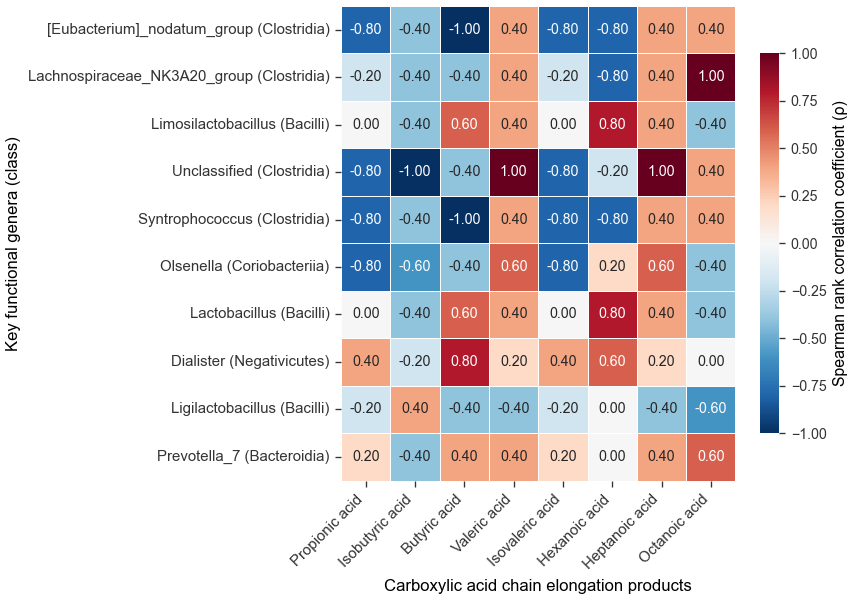

In [83]:
# 1. Prepare and transpose the clean numeric yield matrix (Samples = Rows)
yields_matrix = df_specific_productivity.T # Only available for SBR data

carbon_chain_order = [
    'Propionic acid', 'Isobutyric acid', 'Butyric acid', 'Valeric acid',
    'Isovaleric acid', 'Hexanoic acid', 'Heptanoic acid', 'Octanoic acid'
]
available_mccas = [mcca for mcca in carbon_chain_order if mcca in yields_matrix.columns]

# 2. Select candidate taxa using summed PICRUSt2 predicted functional
# abundance for the carboxylic-acid pathway set (taxon_rel_function_abun;
# NO completeness weighting -- carboxylic_acid_ec's categories share
# extensive, pervasive EC overlap, e.g. caproate/caprylate are 100%
# identical and valerate/heptanoate 92-100%, so a per-category
# completeness fraction would not measure independent pathway presence).
#
# Rebuilt independently from ec_tax0 (not the shared, mutable df2) so this
# cell doesn't depend on what any other cell left df2 as.

_exact_map, _wildcard_map = build_ec_maps(carboxylic_acid_ec)

def _map_ec_to_products_local(ec):
    products = set()
    if ec in _exact_map:
        products.update(_exact_map[ec])
    for prefix, product in _wildcard_map:
        if ec.startswith(prefix):
            products.add(product)
    return list(products)

_ec_tax_cand = ec_tax0.copy()
_ec_tax_cand["mcca_bioproduct"] = _ec_tax_cand["function"].apply(_map_ec_to_products_local)
_df_cand_bp = _ec_tax_cand.explode("mcca_bioproduct").dropna(subset=["mcca_bioproduct"]).copy()
_df_cand_bp = _df_cand_bp[_df_cand_bp["taxon_rel_function_abun"] > 1e-4].copy()

candidate_taxa = (
    _df_cand_bp.groupby("Taxon_genus")["taxon_rel_function_abun"].sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
candidate_taxa = [t for t in candidate_taxa if t in clr_df.columns]
print("Selected candidate taxa (by summed inferred functional abundance):", candidate_taxa)

# 3. Align sample IDs
common = clr_df.index.intersection(yields_matrix.index)
assert len(common) >= 3, "Sample IDs do not match between clr_df and yields matrix!"
X = clr_df.loc[common, candidate_taxa]

# 4. Spearman coefficient matrix
corr_matrix = pd.DataFrame(index=candidate_taxa, columns=available_mccas)
for mcca_product in available_mccas:
    y_mcca = yields_matrix.loc[common, mcca_product]
    for t in candidate_taxa:
        if y_mcca.sum() == 0 or X[t].var() == 0:
            rho = 0.0
        else:
            rho, _ = spearmanr(X[t].values, y_mcca.values)
            if np.isnan(rho):
                rho = 0.0
        corr_matrix.loc[t, mcca_product] = rho
corr_matrix = corr_matrix.astype(float)

# "Genus (Class)" row labels (reuse genus_to_class + genus_display_label)
def genus_display_label(g):
    return "Other" if g == "Other" else f"{g} ({genus_to_class.get(g, 'Unclassified')})"

row_labels = [genus_display_label(t) for t in corr_matrix.index]

# 5. Build heatmap
fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)

annot_labels = corr_matrix.copy().astype(str)
for t in corr_matrix.index:
    for mcca in corr_matrix.columns:
        r = corr_matrix.loc[t, mcca]
        annot_labels.loc[t, mcca] = f"{r:.2f}"

sns.heatmap(
    corr_matrix,
    annot=annot_labels.values,
    fmt="",
    cmap=CMAP_DIVERGING,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Spearman rank correlation coefficient (ρ)', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=row_labels,          # "Genus (Class)" instead of bare genus
    ax=ax,
)

cbar = ax.collections[0].colorbar
cbar.set_label('Spearman rank correlation coefficient (ρ)', size=9.5)
cbar.ax.tick_params(labelsize=8.5)

# No in-figure title (exploratory framing and n belong in the caption, not the image)
ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_specific_productivity_weighted_heatmap")
plt.show()

In [84]:
corr_matrix

,Propionic acid,Isobutyric acid,Butyric acid,Valeric acid,Isovaleric acid,Hexanoic acid,Heptanoic acid,Octanoic acid
[Eubacterium]_nodatum_group,-0.8,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Lachnospiraceae_NK3A20_group,-0.2,-0.4,-0.4,0.4,-0.2,-0.8,0.4,1.0
Limosilactobacillus,0.0,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Unclassified,-0.8,-1.0,-0.4,1.0,-0.8,-0.2,1.0,0.4
Syntrophococcus,-0.8,-0.4,-1.0,0.4,-0.8,-0.8,0.4,0.4
Olsenella,-0.8,-0.6,-0.4,0.6,-0.8,0.2,0.6,-0.4
Lactobacillus,0.0,-0.4,0.6,0.4,0.0,0.8,0.4,-0.4
Dialister,0.4,-0.2,0.8,0.2,0.4,0.6,0.2,0.0
Ligilactobacillus,-0.2,0.4,-0.4,-0.4,-0.2,0.0,-0.4,-0.6
Prevotella_7,0.2,-0.4,0.4,0.4,0.2,0.0,0.4,0.6


### Leave-one-out (LOO) Specific Productivity

Products with fewer than 5 valid samples (LOO drops these to n=3, near the
floor of what Spearman can meaningfully report -- treat as a qualitative stability
indicator only, not a quantitative sensitivity measure):
        product  n_valid_samples
 Propionic acid                4
Isobutyric acid                4
   Butyric acid                4
   Valeric acid                4
Isovaleric acid                4
  Hexanoic acid                4
 Heptanoic acid                4
  Octanoic acid                4

52 of 80 genus-product pairs had a SIGN FLIP under leave-one-out:
                       genus         product  baseline_rho  loo_rho_min  loo_rho_max
                Prevotella_7    Butyric acid           0.4         -0.5          1.0
           Ligilactobacillus    Butyric acid          -0.4         -1.0          0.5
                   Olsenella    Butyric acid          -0.4         -1.0          0.5
                Unclassified    Butyric acid          -0.4         -1.0          

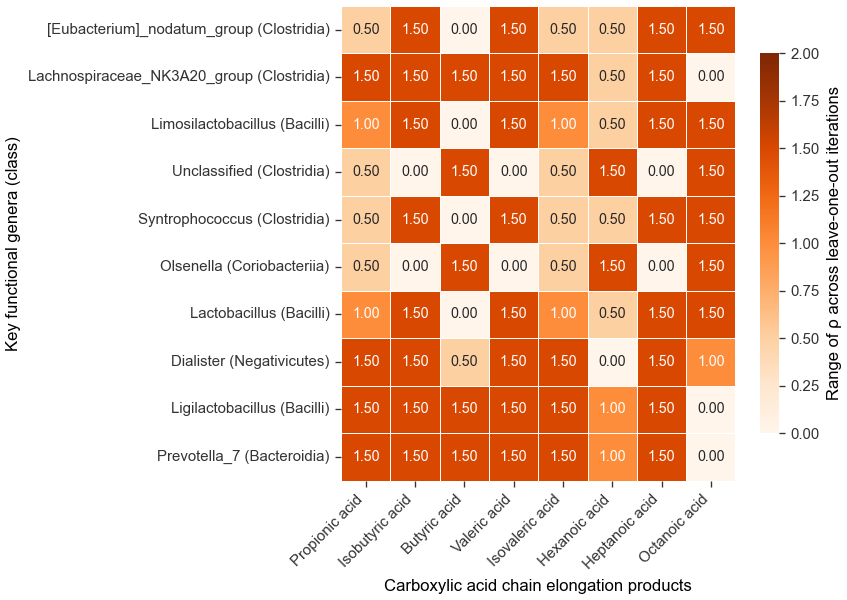

In [85]:
# =====================================================
# Leave-one-out (LOO) sensitivity analysis for the Spearman heatmap above.
#
# At this sample size, any single influential sample can dominate a
# correlation. This recomputes each genus-product rho with one sample
# removed at a time, and reports how much rho moves -- including whether
# its SIGN flips, which is the strongest signal that a reported
# correlation is an artifact of one data point rather than a real trend.
#
# NOTE on thresholds: the baseline correlation requires the full valid
# sample set (MIN_N_FOR_CORR). Each LOO iteration inherently drops to one
# fewer sample by design, so it uses a separate, lower threshold
# (MIN_N_FOR_LOO) -- otherwise, at small total sample sizes (e.g. n=4),
# EVERY LOO iteration falls below the baseline threshold and the entire
# analysis silently returns NaN everywhere (axes/colorbar render, but no
# cells -- exactly the bug this fixes).
# =====================================================

MIN_N_FOR_CORR = 4   # baseline correlation: require the full valid sample set
MIN_N_FOR_LOO = 3     # LOO iterations: inherently n-1 samples relative to baseline

def spearman_dropna(x, y, min_n=MIN_N_FOR_CORR):
    """Spearman correlation after properly dropping any sample with a NaN
    in either x or y. Returns (rho, n_used); rho is np.nan if n_used < min_n
    or if either variable has zero variance among the valid points."""
    mask = ~(pd.isna(x) | pd.isna(y))
    n_used = mask.sum()
    if n_used < min_n:
        return np.nan, n_used
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]
    if np.var(xv) == 0 or np.var(yv) == 0:
        return np.nan, n_used
    rho, _ = spearmanr(xv, yv)
    return rho, n_used


loo_records = []

for mcca_product in available_mccas:
    y_full = yields_matrix.loc[common, mcca_product]
    valid_samples = y_full.dropna().index.tolist()  # samples actually measured for this product
    n_valid = len(valid_samples)

    for t in candidate_taxa:
        x_full = X.loc[valid_samples, t]
        y_valid = y_full.loc[valid_samples]

        # Baseline: full valid sample set, strict threshold
        baseline_rho, baseline_n = spearman_dropna(x_full, y_valid, min_n=MIN_N_FOR_CORR)

        # LOO: each iteration drops one sample -- relaxed threshold
        loo_rhos = []
        for held_out in valid_samples:
            keep = [s for s in valid_samples if s != held_out]
            rho_i, n_i = spearman_dropna(x_full.loc[keep], y_valid.loc[keep], min_n=MIN_N_FOR_LOO)
            loo_rhos.append(rho_i)

        loo_rhos_clean = [r for r in loo_rhos if not np.isnan(r)]

        if loo_rhos_clean:
            rho_min, rho_max = min(loo_rhos_clean), max(loo_rhos_clean)
            rho_range = rho_max - rho_min
            signs = set(np.sign(r) for r in loo_rhos_clean if r != 0)
            sign_flip = len(signs) > 1
        else:
            rho_min = rho_max = rho_range = np.nan
            sign_flip = None

        loo_records.append({
            "genus": t, "product": mcca_product, "n_valid_samples": n_valid,
            "baseline_rho": baseline_rho, "loo_rho_min": rho_min,
            "loo_rho_max": rho_max, "loo_rho_range": rho_range,
            "sign_flip_under_LOO": sign_flip,
        })

loo_df = pd.DataFrame(loo_records)

low_n = loo_df[loo_df["n_valid_samples"] < 5]
if not low_n.empty:
    print(f"Products with fewer than 5 valid samples (LOO drops these to n={MIN_N_FOR_LOO}, near the")
    print("floor of what Spearman can meaningfully report -- treat as a qualitative stability")
    print("indicator only, not a quantitative sensitivity measure):")
    print(low_n[["product", "n_valid_samples"]].drop_duplicates().to_string(index=False))
    print()

flipped = loo_df[loo_df["sign_flip_under_LOO"] == True]
print(f"{len(flipped)} of {len(loo_df)} genus-product pairs had a SIGN FLIP under leave-one-out:")
print(flipped[["genus", "product", "baseline_rho", "loo_rho_min", "loo_rho_max"]]
      .sort_values("product").to_string(index=False))
print()

# ---- Heatmap: range of rho across LOO iterations ----
range_pivot = loo_df.pivot_table(index="genus", columns="product", values="loo_rho_range")
range_pivot = range_pivot.reindex(index=candidate_taxa, columns=available_mccas)

fig, ax = plt.subplots(figsize=FIGSIZE_HEATMAP)
sns.heatmap(
    range_pivot, annot=True, fmt=".2f", cmap="Oranges", vmin=0, vmax=2,
    linewidths=0.5, linecolor="white",
    cbar_kws={'label': 'Range of ρ across leave-one-out iterations', 'shrink': 0.8},
    annot_kws={"size": 8.5},
    yticklabels=[genus_display_label(t) for t in range_pivot.index],
    ax=ax,
)
ax.set_ylabel("Key functional genera (class)")
ax.set_xlabel("Carboxylic acid chain elongation products")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig_dir, "taxa_mcca_loo_sensitivity_range_specific_productivity_heatmap")
plt.show()